# Feature analysis — `ofi_normalised`

This notebook follows the project's **feature-analysis method** (see `template.ipynb` for the full
exposition of the method and the model it feeds) applied to one feature: **`ofi_normalised`**. The
text says what each step does and why; the code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead. Three
crypto exchanges appear — **byb** (Bybit), **bin** (Binance), **okx** (OKX) — and **byb is the
target**: the one we predict. ("Mid-price" = the midpoint between the best buy and best sell quote.)

**The feature.** Order-flow imbalance (OFI) is the net signed pressure on a venue's top of book — how
much size arrived on the bid versus left the ask. We compute it **per exchange** — from *each* venue's
own front_levels — smooth each with a single trade-clock EMA (`ema(OFI_ex)`, swept as a span family)
and then **normalise** so the same number means the same thing in calm and wild markets. Because
there are two regime yardsticks in this project, there are two ways to normalise — and a
feature-analysis notebook should *pick*, not assume. So this notebook **builds and compares three
readings of the same feature**: `ema(OFI)/σ_ev` (vol yardstick), `ema(OFI)/λ_ev` (rate yardstick), and
the un-normalised `ema(OFI)` as a baseline — and lets the hygiene gates say which normalisation (if
any) actually helps.

**Per exchange — the real lead/lag test.** byb's OFI is the target's *own* book pressure; okx's and
bin's are **cross-venue** legs. The template's `price_dislocation` builds one signal per non-byb venue
(OTHERS); here the analogue is *one OFI signal per venue*. byb's leg predicts byb from byb's own flow
(useful, but **circular** with the byb-derived vol/rate controls); the okx and bin legs ask the
genuinely new question — does **another venue's** order-flow *lead* byb's next move? We keep **all
three** venues, sweep the §6 heat-maps per-exchange, and run the §9 per-exchange-vs-single sweep.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the optimized array build really computes what we think it does (validated
  bit-exact against a dead-simple independent streaming build on a real block, **for every per-exchange
  leg**).
- **The hygiene gates (§5/§6)** — the signal is real and holds in any market, not just an echo of
  "the market is busy right now."

## The model these features feed: two heads (recap)

A feature is only worth something if it helps the model predict. We forecast how byb's mid-price
moves over the next ~100 ms, split into two heads:

**Price head — which way and how far?** The *signed* move over the next few price-moves, in units
of byb's recent **volatility** — the **volatility yardstick** `σ_ev` (the exp-weighted RMS of byb's
*actual* mid-moves). Target: `price change ÷ σ_ev`.

**Rate head — how many moves?** The *count* of byb mid-moves over the next 100 ms, against the
recent pace — the **rate yardstick** `λ_ev` (byb's mid-moves per second). Target: `count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing EMA of byb's *volatility* (`σ_ev`) and move *rate*
(`λ_ev`), from past data only — a regime gauge, nothing more. Both are EMAs **decayed on the trade
clock** (`α = 2/(span+1)`) but **updated between trades** (they react to every byb mid-move, so they
read live at every instant), at one fixed span `YARDSTICK_N`. `σ_ev = √(E/W)` over the byb-move
stream; `λ_ev` is the same move-count `W` ÷ an EMA of seconds-per-trade. We reuse **exactly** these
two yardsticks here — both as the price/rate targets *and* as the two normalisers under test. They
are built from **byb's** moves, which is why byb's *own* OFI leg is partly circular with them, and the
okx/bin legs are not (see §5/§6's marginal-value reading).

**Why this matters for OFI.** `ema(OFI)` predicts a venue's *direction* (more bid pressure → it ticks
up), so its home is the price head; but a large *magnitude* of imbalance also tends to precede a burst
of moves, so we check the rate head too. We feed the **signed** feature to both heads.

## 1. What the feature is, and why it might work

| | |
|---|---|
| **what** | a single trade-clock EMA of each venue's level-1 order-flow imbalance, normalised by a byb regime yardstick — one leg per venue (byb / okx / bin) |
| **feeds** | both heads — *direction* (price head: which way byb moves) and *intensity* (rate head: how many moves); both fed the *signed* feature |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** *Order-flow imbalance* (OFI) measures, between two consecutive top-of-book snapshots,
the **net signed size pressure** at the best bid and ask: size added on the bid and size removed
from the ask both push the price **up**; the reverse pushes it **down**. We use the level-1
**Cont–Kukanov–Stoikov** OFI (Cont, Kukanov & Stoikov, 2014, *J. Financial Econometrics*): for a
move from a previous top-of-book (`prev`) to the current one (`cur`),

`e = (cur_bid_prc ≥ prev_bid_prc ? cur_bid_qty : 0) − (cur_bid_prc ≤ prev_bid_prc ? prev_bid_qty : 0) − (cur_ask_prc ≤ prev_ask_prc ? cur_ask_qty : 0) + (cur_ask_prc ≥ prev_ask_prc ? prev_ask_qty : 0)`

Each term reads as a story: if the **bid price rose**, all of the new bid size is fresh demand
(`+cur_bid_qty`); if the **bid price held or fell**, the old bid size was consumed or cancelled
(`−prev_bid_qty`); symmetrically for the ask (an ask price that **fell** means fresh supply pushing
down, `−cur_ask_qty`; an ask that **held or rose** means the old ask cleared, `+prev_ask_qty`). The
sum `e` is positive when buy pressure dominates. We smooth `e` with one trade-clock EMA and divide
by a yardstick — **once per venue**.

**Why it should work, and why per-exchange.** OFI is the most direct microstructure read on *who is
winning right now* at the touch, and the classic result (Cont–Kukanov–Stoikov) is that
**contemporaneous price change is close to linear in OFI**. The open question for *us* is predictive,
at ~100 ms — and it has two flavours:
- **byb's own OFI → byb** (the target reading byb's own pressure): a persistent bid-side imbalance on
  byb should pull byb's mid up over the next beat. Strong, but **circular** with byb's vol/rate
  controls (both are built from byb's own activity).
- **okx / bin OFI → byb** (the **cross-venue lead/lag** legs): does *another* venue's order-flow move
  *before* byb does? This is the genuinely new question — the same lead/lag idea the template's
  cross-venue gap exploits, but read through order-flow instead of price.

> **No fixed leader (per the guard rails).** Leadership rotates — any venue can lead at any moment. So
> we build OFI **the same way for every venue and keep all three**; we never hard-code one as the
> leader, and we never pick "the best venue." §6 sweeps all three; §9 asks *when* keeping them
> separate pays off.

**Why normalise, and the dimensional caveat.** Raw OFI is a **size** (contracts), and quiet markets
post smaller quotes than busy ones, so the *same* imbalance reads bigger in a busy regime — that's
regime contamination we want gone. Dividing by a yardstick rescales it to be **comparable across
regimes**. But note the caveat plainly: `σ_ev` is a *return* (per move) and `λ_ev` is a *rate* (moves
per second) — neither shares units with a size, so **this normalisation is for regime-comparability,
not dimensional consistency**. The division is a *regime gauge*, not a units conversion; we test
empirically whether the vol gauge, the rate gauge, or neither actually helps.

**What would disprove it.** No predictive power for `ema(OFI)` at any span, on either head; or power
that vanishes once we account for how volatile / busy the market is (meaning it only tracked the
regime). For the **cross-venue legs** specifically: the test is whether okx/bin OFI add over byb's
controls *and over byb's own OFI leg* — if they add ≈0, there is no exploitable cross-venue order-flow
lead at this horizon; if they add materially (as they do here), the cross-venue lead is real.

## Choosing the EMA — and why OFI is a *flow*, read `E/W`

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every event in between**, so a read between trades is
never stale. Two choices decide whether the EMA is even *correct*; a wrong one fails **silently**.

**OFI is a sparse FLOW**, exactly like `σ_ev`. It is defined only on a venue's **book updates** (a new
top-of-book), not on every event, and we want the *average imbalance per book update* — not a sum
that grows with how chatty that venue's quote feed is. So `ema(OFI_ex)` is a **`KernelMeanEMA`** read
as the self-normalising ratio `E / W`:
- `add(e)` on **each book update for venue `ex`** (weight 1) — `E` accumulates exp-weighted OFI, `W`
  counts the book updates;
- `tick()` once per **trade-timestamp** (the SHARED clock — every venue's trades) — decay both `E`/`W`;
- read `ema(OFI_ex) = E / W` = the **per-book-update mean OFI** for venue `ex` as of now.

Dividing by `W` does the same two jobs it does for `σ_ev`: it cancels the in-between (foreign-event)
decay exactly — so on the *combined* trade clock at span `N` you recover that venue's *own*-clock OFI
EMA at a rescaled span, **roughly `N` times that venue's share of the combined trade rate** (so the
same `N` reads a longer own-clock memory for a thinly-traded venue like okx, shorter for bin) — and it
removes a fresh EMA's warm-up bias. (Pushing a `0` on non-book events instead would silently turn
"imbalance per book update" into "imbalance per trade," contaminated by the trade rate.) This is
*not* a level (a forward-filled price/gap), so it is **not** a `LiveFrontEMA`; it is a flow, so it is
a `KernelMeanEMA` — the same class as `σ_ev`.

The two between-trade rules still hold: **records sharing a timestamp are ONE event** (we collapse
each venue's front_levels to one row per `rx_time` — its final top-of-book — before forming
consecutive-pair OFI, so a same-instant burst of snapshots is one update, not a sequence of phantom
moves), and a timestamp with trades advances the decay clock **once**, not once per print.

## 2. The exact definition

**Causal** — every value uses only book updates and trades at-or-before the moment it is read; no
forward-fill of the future. **On the trade clock** — progress is counted in trade-timestamps, so the
EMA's memory is in trades, not seconds. **Comparable across regimes** — OFI is a raw size, so we divide
by a yardstick (and compare which one). **Per venue** — one OFI leg each for byb / okx / bin.

Putting it together, for each venue `ex`:

**2a — The shape** (one line, three readings of the same OFI EMA):

- `ofi_raw[ex] = ema(OFI_ex)`                         — the un-normalised baseline (a size)
- `ofi_over_sigma[ex] = ema(OFI_ex) / σ_ev`           — variant **(A)**, vol yardstick
- `ofi_over_lambda[ex] = ema(OFI_ex) / λ_ev`          — variant **(B)**, rate yardstick

`ema(OFI_ex)` is one trade-clock EMA of venue `ex`'s OFI flow (span swept as a family). `σ_ev` and
`λ_ev` are read at the grid anchor — the *same* (byb-derived) yardsticks the model's two heads use,
for **every** venue's leg (we predict byb, so we normalise by byb's regime even for okx/bin OFI).

**2b — The pieces, and how they update:**

- **`ema(OFI_ex)`** is a **`KernelMeanEMA`** read `E/W`: `add(e)` on every venue-`ex` book update (OFI
  computed from `ex`'s front_levels consecutive top-of-book rows), `tick()` once per trade-timestamp
  on the SHARED clock, read `E/W` = mean OFI per `ex` book update. Reacts to every `ex` book update;
  decays on the shared trade clock.
- **`σ_ev`, `λ_ev`** are the project yardsticks — each a **`KernelMeanEMA`** `E/W` over **byb's**
  mid-move stream (push `return²` / `1` only on a real byb move; decay every trade): `σ_ev = √(E/W)` =
  RMS move per move; `λ_ev = W ÷ (seconds-per-trade EMA)` = byb moves per second. Span `YARDSTICK_N`.

§3 builds exactly this (all three readings × three venues, across the span family); §4 re-derives
`ema(OFI_ex)` from raw events with an independent streaming build and confirms it bit-exact on a real
block **for every venue**.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as
`E/W` flows on that clock at span `YARDSTICK_N` — verbatim from the template's machinery.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict — and whose moves define the yardsticks/targets
EXCHANGES   = ["byb", "okx", "bin"]              # OFI is computed per venue; byb = own-book leg, okx/bin = CROSS-VENUE lead/lag legs
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH (byb) yardsticks (σ_ev, λ_ev): trade-tick EMA (α=2/(N+1))
SPANS       = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]   # the FULL ema(OFI) span family to sweep (trades) — picked per head off the grid
N_GRID      = 40000                              # reduced eval grid for iteration speed (50 ms anchors); the §4 oracle still runs on the real block
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data
print("block:", block)

# the trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in ("bin", "byb", "okx"):
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# byb mid stream (merged_levels: trade-augmented, fresher) — used ONLY for the yardsticks + targets (the OFI itself needs qty, so it uses front_levels below)
byb_mer = (load_block(block, TARGET, "merged_levels").select("rx_time", "bid_prc", "ask_prc").drop_nulls())
byb_rx0 = byb_mer["rx_time"].cast(pl.Int64).to_numpy()
byb_mid0 = (byb_mer["bid_prc"].to_numpy() + byb_mer["ask_prc"].to_numpy()) / 2

# Both yardsticks react to EVERY byb merged-mid change; decay once per TRADE but INJECT on every byb mid-move.
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, rx_inj, span):   # EWMA of `val` over an event stream `rx_inj`, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, rx_inj, "left")                              # trades strictly before each event (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the event stream (the partial epoch)
    partial = cs[np.searchsorted(rx_inj, anchors, "right")] - cs[np.searchsorted(rx_inj, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, mv_rx, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), mv_rx, span)    # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades")

block: holocron.20260520T135822.0


trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
yardsticks: react to every byb mid-move; decay span 10000 trades


### Build the OFI flow — per venue

Now the feature-specific part, **for each venue**: load that venue's raw **front_levels** (the only
stream with `bid_qty` / `ask_qty` — `merged_levels` is price-only by design), collapse same-`rx_time`
bursts to one row (its final top-of-book), form the Cont–Kukanov–Stoikov `e` on each consecutive pair,
and inject it as a flow on the SHARED trade clock. `_flow_at` (above) gives the committed-`E`/`W` read
at any anchor; `ema(OFI_ex)` is the ratio. This is the same `E/W` machine as the yardsticks, fed each
venue's OFI stream. We store the per-venue OFI streams in dicts keyed by exchange.

In [2]:
# Per-venue OFI flow. Each venue's front_levels is the ONLY stream carrying bid_qty/ask_qty (merged_levels is price-only).
ofi_rx_by_ex = {}    # ex -> rx_time of each OFI event (the cur row's rx)
ofi_e_by_ex  = {}    # ex -> the Cont–Kukanov–Stoikov e for each event
raw_fl_by_ex = {}    # ex -> (frx0, bp0, bq0, ap0, aq0) raw un-collapsed columns (for the §4 oracle)
for ex in EXCHANGES:
    fl = (load_block(block, f"{ex}_{COIN}", "front_levels")
          .select("rx_time", "bid_prc", "bid_qty", "ask_prc", "ask_qty").drop_nulls())
    frx0 = fl["rx_time"].cast(pl.Int64).to_numpy()
    bp0, bq0, ap0, aq0 = (fl[c].to_numpy() for c in ("bid_prc", "bid_qty", "ask_prc", "ask_qty"))
    raw_fl_by_ex[ex] = (frx0, bp0, bq0, ap0, aq0)
    fl_keep = np.concatenate([frx0[1:] != frx0[:-1], [True]])                    # last row per rx_time = ONE event per timestamp
    frx, bp, bq, ap, aq = frx0[fl_keep], bp0[fl_keep], bq0[fl_keep], ap0[fl_keep], aq0[fl_keep]
    # level-1 Cont–Kukanov–Stoikov OFI on each consecutive top-of-book pair (prev -> cur). First row has no prev -> dropped.
    ofi_rx_by_ex[ex] = frx[1:]                                                   # OFI for cur row is stamped at cur's rx_time
    ofi_e_by_ex[ex]  = (np.where(bp[1:] >= bp[:-1], bq[1:], 0.0) - np.where(bp[1:] <= bp[:-1], bq[:-1], 0.0)
                        - np.where(ap[1:] <= ap[:-1], aq[1:], 0.0) + np.where(ap[1:] >= ap[:-1], aq[:-1], 0.0))
    print(f"  {ex}: {len(ofi_e_by_ex[ex]):,} book updates,  median e {np.median(ofi_e_by_ex[ex]):+.2f},  std {ofi_e_by_ex[ex].std():.1f}")

def ema_ofi(ex, anchors, span):                   # ema(OFI_ex) = E/W: KernelMeanEMA over venue ex's OFI flow, decayed on the SHARED trade clock, read at each anchor
    E = _flow_at(anchors, ofi_e_by_ex[ex], ofi_rx_by_ex[ex], span)              # exp-weighted OFI
    W = _flow_at(anchors, np.ones_like(ofi_e_by_ex[ex]), ofi_rx_by_ex[ex], span)  # exp-weighted book-update count
    return E / np.maximum(W, 1e-12)                                              # per-book-update mean OFI (W cancels foreign-event decay + warm-up bias)

  byb: 1,378,360 book updates,  median e +0.01,  std 58.5
  okx: 2,043,291 book updates,  median e -0.00,  std 124.8


  bin: 9,350,159 book updates,  median e +0.00,  std 39.9


## 3. Build it (twice)

Build the feature two ways: the fast array version above for analysis, and — in §4 — a streaming
version that does constant work per event (no growing buffers), which has to agree, **for each venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; adjacent
100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated, which is exactly
why §5's walk-forward gate uses an embargo), read byb's actual move over the next 100 ms (the price
head's target), the move *count* (the rate head's target), and compute all three feature readings at
each grid point and span, **for every venue**.

In [3]:
# evaluation grid (causal) + both forward targets in yardstick units
WARMUP = 5 * max(YARDSTICK_N, max(SPANS))   # enough trades for the slowest EMA/yardstick to converge
full_anchor = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup
anchor_ts   = full_anchor[:N_GRID]                                                       # reduced grid for iteration speed
print(f"grid: {len(anchor_ts):,} anchors (of {len(full_anchor):,} available; reduced for speed)")

sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both (byb) yardsticks at each grid point (span YARDSTICK_N)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms signed log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor

# rate-head target: byb mid-move count in the next 100 ms ÷ λ_ev
fwd_count   = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
               - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)

# the three readings of the feature, per venue × span: un-normalised baseline, /σ_ev (A), /λ_ev (B)
def ofi_raw(ex, span):          return ema_ofi(ex, anchor_ts, span)                        # baseline (a size)
def ofi_over_sigma(ex, span):   return ema_ofi(ex, anchor_ts, span) / sigma_at_anchor      # variant A — vol yardstick
def ofi_over_lambda(ex, span):  return ema_ofi(ex, anchor_ts, span) / lam_at_anchor        # variant B — rate yardstick
VARIANTS = {"none (raw)": ofi_raw, "/ σ_ev (vol)": ofi_over_sigma, "/ λ_ev (rate)": ofi_over_lambda}
print("three readings ready, per venue:", list(VARIANTS), "x", EXCHANGES)

grid: 40,000 anchors (of 1,706,369 available; reduced for speed)
σ_ev median 2.89e-05,  λ_ev median 5.68 moves/s
three readings ready, per venue: ['none (raw)', '/ σ_ev (vol)', '/ λ_ev (rate)'] x ['byb', 'okx', 'bin']


## 4. Check the code is right — the oracle (an independent plain-numpy streaming build, every venue)

**Non-negotiable.** Reproduce `ema(OFI_ex)` with a second, **independent** implementation and confirm
the two agree on real data — **for every venue, at the shipped span**. The oracle is a dead-simple O(1)
state machine you push **raw events** into — `on_book(bid_prc, bid_qty, ask_prc, ask_qty)` for *this
venue's* top-of-book update, `on_trade()` for any trade (the shared clock) — and read the current
`ema(OFI)` from `value()`. It uses **no production helpers** (no `boba.ema`, no `_flow_at`): the `E/W`
decay is written out by hand as two scalars, so it shares **no code** with the §3 vectorized path. It
computes the OFI `e` **itself** from its own held previous top-of-book (it never sees §3's `ofi_e`
array), so it is a genuinely independent check of the OFI formula *and* the trade-clock `E/W` decay —
implementable from the §2 description alone.

**The design:**
- One `LiveOFI` instance **per venue**, each holding *its own* previous top-of-book; on each new book
  state for that venue it forms the Cont–Kukanov–Stoikov `e` and folds it into a hand-rolled `E/W` flow
  EMA (`E += α·e`, `W += α`; decay `E,W *= (1−α)` once per trade-tick; `value() = E/W`) — the same
  textbook bias-corrected EWMA-mean `σ_ev` uses, but reimplemented from scratch here.
- Events sharing a **timestamp are one event**: the driver applies them all, then advances the clock
  **at most once** (and only if a trade landed, on the shared clock). A book-only instant injects OFI
  but does not tick. **Every** venue's instance ticks on **every** trade-timestamp (the shared clock),
  but only injects on its *own* book updates.
- `value()` returns `ema(OFI) = E/W` — the per-book-update mean OFI for that venue, current at the
  instant read.

This validates the **un-normalised `ema(OFI_ex)`** for each venue; the §3 normalised variants are just
that number ÷ a yardstick, and the yardsticks are the template's already-validated machinery, so
reproducing every `ema(OFI_ex)` bit-exact validates all readings. **The oracle runs on the FULL real
block** (all events, no grid truncation), is read at every grid anchor for each venue, and is checked at
the **shipped span** (the §6 winner) plus a mid and a long span — honest coverage across the family.

In [4]:
# INDEPENDENT oracle — dead-simple plain-numpy streaming reimplementation. NO production helpers (no boba.ema),
# NO shared code with §3's _flow_at. The E/W decay is written out by hand: two scalars E, W; add(e) does
# E += α·e, W += α; tick() does E *= (1-α), W *= (1-α); value() = E/W. This is the textbook bias-corrected
# EWMA mean of a sparse flow, implementable from the feature description alone — a genuine cross-check of both
# the Cont–Kukanov–Stoikov e formula AND the trade-clock E/W decay.
class LiveOFI:
    # Pure feature state machine for ema(OFI) of ONE venue. Holds that venue's previous top-of-book; on each
    # new book state it computes the level-1 Cont–Kukanov–Stoikov e ITSELF and injects it into a hand-rolled
    # E/W flow EMA. The driver calls refresh() once per timestamp: apply all the timestamp's events, then
    # advance the SHARED trade clock AT MOST ONCE (decay E,W) — only if a trade landed (any venue). State is O(1), all scalar.
    def __init__(self, span):
        self.alpha = 2.0 / (span + 1.0)               # α = 2/(span+1)
        self.E = 0.0; self.W = 0.0                     # ema(OFI) = E/W, both decayed per trade-tick
        self.pbp = self.pbq = self.pap = self.paq = None   # previous top-of-book (this venue)
        self.cbp = self.cbq = self.cap = self.caq = None   # current (this timestamp's) top-of-book
        self.book_changed = False                     # did THIS venue's book update land this timestamp?
        self.traded = False                           # did ANY trade land this timestamp? -> exactly one decay

    def on_book(self, bid_prc, bid_qty, ask_prc, ask_qty):   # this venue's BBO update -> stage the current top-of-book (last wins within a timestamp)
        self.cbp, self.cbq, self.cap, self.caq = bid_prc, bid_qty, ask_prc, ask_qty
        self.book_changed = True

    def on_trade(self):                                # ANY venue's trade -> the shared clock advances once this timestamp
        self.traded = True

    def refresh(self):                                 # ONE per TIMESTAMP: inject OFI for this timestamp's final book, then tick at most once
        if self.book_changed:
            if self.pbp is not None:                   # need a previous book to form e
                e = ((self.cbq if self.cbp >= self.pbp else 0.0) - (self.pbq if self.cbp <= self.pbp else 0.0)
                     - (self.caq if self.cap <= self.pap else 0.0) + (self.paq if self.cap >= self.pap else 0.0))
                self.E += self.alpha * e               # inject OFI on this book update (weight 1): E += α·e, W += α
                self.W += self.alpha
            self.pbp, self.pbq, self.pap, self.paq = self.cbp, self.cbq, self.cap, self.caq   # roll prev <- cur
            self.book_changed = False
        if self.traded:
            self.E *= (1.0 - self.alpha)               # a trade landed -> decay E,W exactly once
            self.W *= (1.0 - self.alpha)
            self.traded = False

    def value(self):
        return self.E / self.W if self.W > 0.0 else float("nan")   # ema(OFI) = E/W (nan before the first book update)

# --- the shared trade clock: every venue's trades (for the on_trade ticks) ---
# Validate the SHIPPED span (the shortest of the family, SPANS[0]=10 — the §6 grid winner per venue, confirmed below)
# AND a mid + long span, for honest coverage spanning the whole family — all for EVERY venue, on the FULL block.
SHIPPED_SPAN = SPANS[0]                                # the short end the §6 sweep selects (verified in §6's per-exchange print)
SPAN_CHECKS  = sorted({SHIPPED_SPAN, SPANS[len(SPANS) // 2], SPANS[-1]})   # shipped + mid + slowest span; the mechanism is span-agnostic, coverage is honest
tr_all = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))
    tr_all.append(td["rx_time"].cast(pl.Int64).to_numpy())
tr_rx_all = np.concatenate(tr_all)

print(f"oracle: independent plain-numpy streaming ema(OFI) per venue, spans {SPAN_CHECKS} (incl. SHIPPED span {SHIPPED_SPAN}), on the FULL block")
oracle_diffs = {}
for ex in EXCHANGES:
    # raw (un-collapsed) front_levels for THIS venue; collapse handled by the driver (one refresh per timestamp)
    frx0, bp0, bq0, ap0, aq0 = raw_fl_by_ex[ex]
    # merge book + trade events by rx; book (kind 0) before trade (kind 1) on ties
    allrx = np.concatenate([frx0, tr_rx_all])
    kindL = np.concatenate([np.zeros(len(frx0), np.int8), np.ones(len(tr_rx_all), np.int8)])
    bk_idx = np.concatenate([np.arange(len(frx0)), -np.ones(len(tr_rx_all), np.int64)]).astype(np.int64)  # row index into raw fl arrays
    o = np.lexsort((kindL, allrx))
    allrxL, kindLs, bk_idxL = allrx[o].tolist(), kindL[o].tolist(), bk_idx[o].tolist()
    bp_l, bq_l, ap_l, aq_l = bp0.tolist(), bq0.tolist(), ap0.tolist(), aq0.tolist()   # raw front_levels columns
    na = len(anchor_ts)

    for span in SPAN_CHECKS:
        feat = LiveOFI(span)
        stream = np.full(na, np.nan)
        n = len(allrxL); i = 0; ai = 0
        while i < n:
            rx = allrxL[i]
            while ai < na and anchor_ts[ai] < rx:      # read every anchor whose state is settled (all events before rx applied)
                stream[ai] = feat.value(); ai += 1
            while i < n and allrxL[i] == rx:           # apply EVERY event stamped at this nanosecond
                if kindLs[i] == 0:
                    j = bk_idxL[i]; feat.on_book(bp_l[j], bq_l[j], ap_l[j], aq_l[j])
                else:
                    feat.on_trade()
                i += 1
            feat.refresh()                             # apply the timestamp: inject OFI for the final book, tick once if any trade landed
        while ai < na:
            stream[ai] = feat.value(); ai += 1

        ref = ema_ofi(ex, anchor_ts, span)             # the §3 vectorized ema(OFI) at the same span
        both = np.isfinite(stream) & np.isfinite(ref)
        diff = np.abs(stream[both] - ref[both])
        md = float(np.nanmax(diff))
        oracle_diffs[(ex, span)] = md
        tag = " (SHIPPED)" if span == SHIPPED_SPAN else ""
        print(f"  {ex} span {span:>3}{tag}:  max |diff| {md:.2e}  on {int(both.sum()):,} grid points")
        assert md < 1e-9, f"independent oracle does not reproduce vectorized ema(OFI) for {ex} span {span}"
print(f"oracle: independent streaming build reproduces ema(OFI) for ALL venues x spans  OK "
      f"(bit-exact, max over all {max(oracle_diffs.values()):.2e})")

oracle: independent plain-numpy streaming ema(OFI) per venue, spans [10, 200, 5000] (incl. SHIPPED span 10), on the FULL block


  byb span  10 (SHIPPED):  max |diff| 1.28e-11  on 40,000 grid points


  byb span 200:  max |diff| 1.29e-12  on 40,000 grid points


  byb span 5000:  max |diff| 6.59e-13  on 40,000 grid points


  okx span  10 (SHIPPED):  max |diff| 7.18e-12  on 40,000 grid points


  okx span 200:  max |diff| 6.68e-13  on 40,000 grid points


  okx span 5000:  max |diff| 1.17e-12  on 40,000 grid points


  bin span  10 (SHIPPED):  max |diff| 3.95e-12  on 40,000 grid points


  bin span 200:  max |diff| 3.45e-13  on 40,000 grid points


  bin span 5000:  max |diff| 1.85e-12  on 40,000 grid points
oracle: independent streaming build reproduces ema(OFI) for ALL venues x spans  OK (bit-exact, max over all 1.28e-11)


**Conclusion.** From the raw event stream — each venue's front_levels book updates (the independent
plain-numpy oracle computes the Cont–Kukanov–Stoikov `e` itself from its own held previous top-of-book)
plus every venue's trades ticking the shared clock — the O(1) state machine reproduces the vectorized
`ema(OFI_ex)` to floating-point precision **for all three venues at every checked span (incl. the shipped
span)** — max |diff| ~1e-12, pure round-off from the EMA's recursive last-digit drift. The "records
sharing a timestamp are one event" rule and the "one decay per trade-timestamp" rule are both enforced in
`refresh()`. Because the oracle shares no code with §3 (the `E/W` decay is hand-rolled, not `boba.ema`),
this is a genuine cross-check: the §3 build computes exactly what we think it does for every venue, and
the normalised readings (just that number ÷ a yardstick) are trustworthy.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts *something
the market's current state doesn't already tell us*. We build four "control" signals from the recent
past — **rate momentum / level** (from `λ_ev`) and **vol momentum / level** (from `σ_ev`) — then
measure each venue's OFI feature's power **on top of** them.

> **Circular vs cross-venue — read this before trusting the byb leg.** The controls (`σ_ev`, `λ_ev`
> and their momenta) are built from **byb's own** mid-moves. byb's OFI is *also* byb's own activity, so
> **byb's leg is partly circular with the controls** — a high marginal IC there is expected and is
> not, on its own, evidence of a tradeable cross-venue lead. The **okx and bin legs are NOT circular**:
> they are *another* venue's order-flow, so any marginal IC they add over byb's controls is the
> genuinely new, cross-venue lead/lag signal. §6's per-exchange marginal-value table reports each
> honestly; the headline question is whether the **cross-venue** legs add real value or collapse to ≈0.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman — robust to
outliers), scored **out-of-sample with a purged, embargoed, expanding-window walk-forward** (strictly
past → future), exactly as in the template. The embargo clears the 100 ms outcome windows so
overlapping forward targets can't straddle a train→test boundary. Verbatim machinery follows.

In [5]:
# --- the four control signals: the two (byb) yardsticks (level) plus a fast/slow momentum of each ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.011  momenta+levels 0.006  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal — that's what
we want: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows *on top of*
these controls is genuinely new information, not the regime wearing a disguise. The one caveat (above)
is the **byb leg**, which shares its source (byb's own activity) with the controls — so for byb the
"new information" framing is weaker. The okx/bin legs have no such overlap.

## 6. Three choices: which span per head, which normalisation, and which venues

`ofi_normalised` now has a real per-exchange axis, so there are **three** choices, and this is the
section that makes them:

1. **Which span?** OFI is a family across time-scales (the full `SPANS` family); we sweep the whole
   grid and pick **per head off the grid** (no hand-picked spans).
2. **Which normalisation?** `none` (raw), `/σ_ev` (vol), `/λ_ev` (rate). We compare all three.
3. **Which venues?** byb (own book), okx, bin (cross-venue). We keep **all** and report each.

We check two things per venue/span/variant:
- does the **signed** feature predict *direction* — which way (and how far) byb moves next (price head)?
- does its **magnitude** predict *intensity* — *how many* moves byb makes next (rate head)?

The magnitude check is a **diagnostic only**: the model is fed the *signed* feature for both heads.
We draw the span × venue sweep as heat-maps, one per head, for the **best-by-|IC| variant** at each
cell (so a single panel reads cleanly); the per-variant numbers feed the §6-gate table below.

> **Note on rank-invariance.** Spearman rank-IC is invariant to any *strictly monotone, sample-wide*
> rescale, but dividing by `σ_ev`/`λ_ev` is a *per-row* rescale (a different divisor each grid point),
> so it genuinely **re-orders** the samples — the three variants are honestly different signals, and
> the heat-map differences are real, not an artefact.

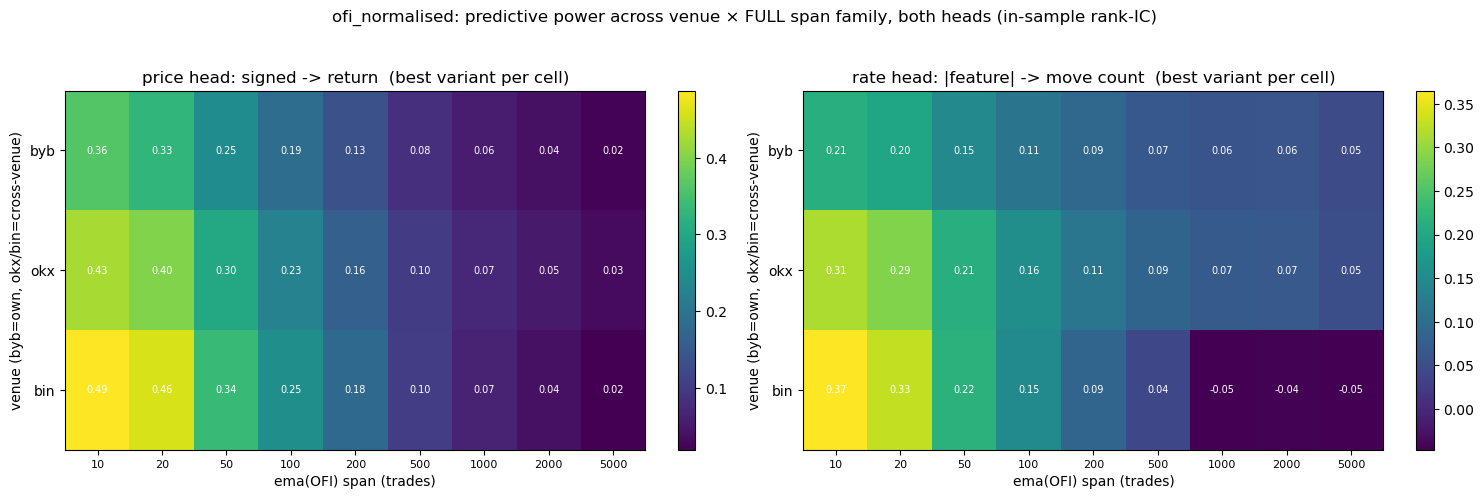

price head: overall best = 'none (raw)' on bin @ span 10  (in-sample IC +0.488)
rate  head: overall best = 'none (raw)' on bin @ span 10  (in-sample IC +0.365)
per-exchange best (price head), picked off the full grid:
  byb: 'none (raw)' @ span 10  (in-sample IC +0.363)
  okx: 'none (raw)' @ span 10  (in-sample IC +0.426)
  bin: 'none (raw)' @ span 10  (in-sample IC +0.488)


In [6]:
# Sweep venue × span × normalisation, BOTH heads. price head: signed feature -> byb's signed return; rate head: |feature| -> move count.
# Store full cube: grids[head][variant][ex] is a length-len(SPANS) array of IC.
price_cube = {nm: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for nm in VARIANTS}
rate_cube  = {nm: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for nm in VARIANTS}
feat_cache = {}   # (nm, ex, span) -> feature array (reused by the gates/§9)
for nm, fn in VARIANTS.items():
    for ex in EXCHANGES:
        for j, span in enumerate(SPANS):
            d = fn(ex, span); feat_cache[(nm, ex, span)] = d
            ok = np.isfinite(d)
            price_cube[nm][ex][j] = spearmanr(d[ok], target[ok]).statistic
            rate_cube[nm][ex][j]  = spearmanr(np.abs(d[ok]), rate_target[ok]).statistic

# Per (head, venue, span) collapse to the BEST variant by |IC|, for a clean per-exchange heat-map across the FULL span family.
def best_variant_grid(cube):
    G = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}
    which = {ex: [None] * len(SPANS) for ex in EXCHANGES}
    for ex in EXCHANGES:
        for j in range(len(SPANS)):
            vals = [(cube[nm][ex][j], nm) for nm in VARIANTS if np.isfinite(cube[nm][ex][j])]
            if vals:
                v, nm = max(vals, key=lambda t: abs(t[0])); G[ex][j] = v; which[ex][j] = nm
    return G, which
price_G, price_which = best_variant_grid(price_cube)
rate_G,  rate_which  = best_variant_grid(rate_cube)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (G, head) in zip(axes, [(price_G, "price head: signed -> return"), (rate_G, "rate head: |feature| -> move count")]):
    M = np.vstack([G[ex] for ex in EXCHANGES])
    im = ax.imshow(M, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8); ax.set_xlabel("ema(OFI) span (trades)")
    ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels(EXCHANGES); ax.set_ylabel("venue (byb=own, okx/bin=cross-venue)")
    ax.set_title(head + "  (best variant per cell)")
    for i in range(len(EXCHANGES)):
        for j in range(len(SPANS)):
            if np.isfinite(M[i, j]): ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="w", fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("ofi_normalised: predictive power across venue × FULL span family, both heads (in-sample rank-IC)", y=1.03)
fig.tight_layout(); plt.show()

# pick the best (venue, variant, span) PER HEAD off the FULL grid — IN-SAMPLE, used ONLY to choose; re-scored OUT-OF-SAMPLE below.
def best_cell(cube):
    flat = [(cube[nm][ex][j], nm, ex, j) for nm in VARIANTS for ex in EXCHANGES for j in range(len(SPANS)) if np.isfinite(cube[nm][ex][j])]
    v, nm, ex, j = max(flat, key=lambda t: abs(t[0]))   # abs: the price head can be negatively signed; keep the strongest |IC|
    return nm, ex, j, v
# per-exchange best (variant, span) per head — picked off the grid for EACH venue
def best_cell_for(cube, ex):
    flat = [(cube[nm][ex][j], nm, j) for nm in VARIANTS for j in range(len(SPANS)) if np.isfinite(cube[nm][ex][j])]
    v, nm, j = max(flat, key=lambda t: abs(t[0])); return nm, j, v
p_nm, p_ex, p_j, p_v = best_cell(price_cube)
r_nm, r_ex, r_j, r_v = best_cell(rate_cube)
print(f"price head: overall best = '{p_nm}' on {p_ex} @ span {SPANS[p_j]}  (in-sample IC {p_v:+.3f})")
print(f"rate  head: overall best = '{r_nm}' on {r_ex} @ span {SPANS[r_j]}  (in-sample IC {r_v:+.3f})")
print("per-exchange best (price head), picked off the full grid:")
for ex in EXCHANGES:
    nm, j, v = best_cell_for(price_cube, ex)
    print(f"  {ex}: '{nm}' @ span {SPANS[j]}  (in-sample IC {v:+.3f})")

### Signal lifetime across the WHOLE family — IC *and* half-life at every span

The IC heat-map above answers "how strong?" at each span, but a strong IC is only tradeable if it
**lasts**: a span can post a high IC that is mostly the move already underway at the anchor (a short
*latency budget*), or a lower IC that survives tens of ms of observe→act latency (a long budget). **Both
are useful** — so we measure both, **per span, per venue, per head**, not just at one chosen N.

For every `(variant, venue, span)` we read the feature at the anchor (causal, unchanged) and slide the
*outcome* window forward by a latency `δ`: the **forward IC** against byb's outcome over
`[anchor+δ, anchor+δ+100 ms]`, for `δ ∈ {0,5,10,20,50,100,200,500} ms`. Three numbers summarise each cell:

- **IC@δ=0** — the headline edge (what the §6 heat-map shows);
- **edge@20 ms** — the forward IC after a realistic ~20 ms observe→act latency (the realisable edge);
- **half-life** — the first `δ` where `|forward IC|` falls below half its `δ=0` value (`>500 ms` if it
  never does) — *how long the edge lasts*.

We also keep the **backward IC** (against the already-happened `[anchor−100 ms, anchor]` move) per cell:
a forward IC that dies at `δ>0` while the backward IC stays high is a **contemporaneous echo**, not a
prediction. We run this on the **40k-anchor diagnostic grid** (`anchor_ts`) for speed. Heads use their
natural reading: the **signed** OFI → forward signed-return IC (price head), **|OFI|** → forward
move-count IC (rate head).

family lifetime cube built: {'price': 81, 'rate': 81} cells per head


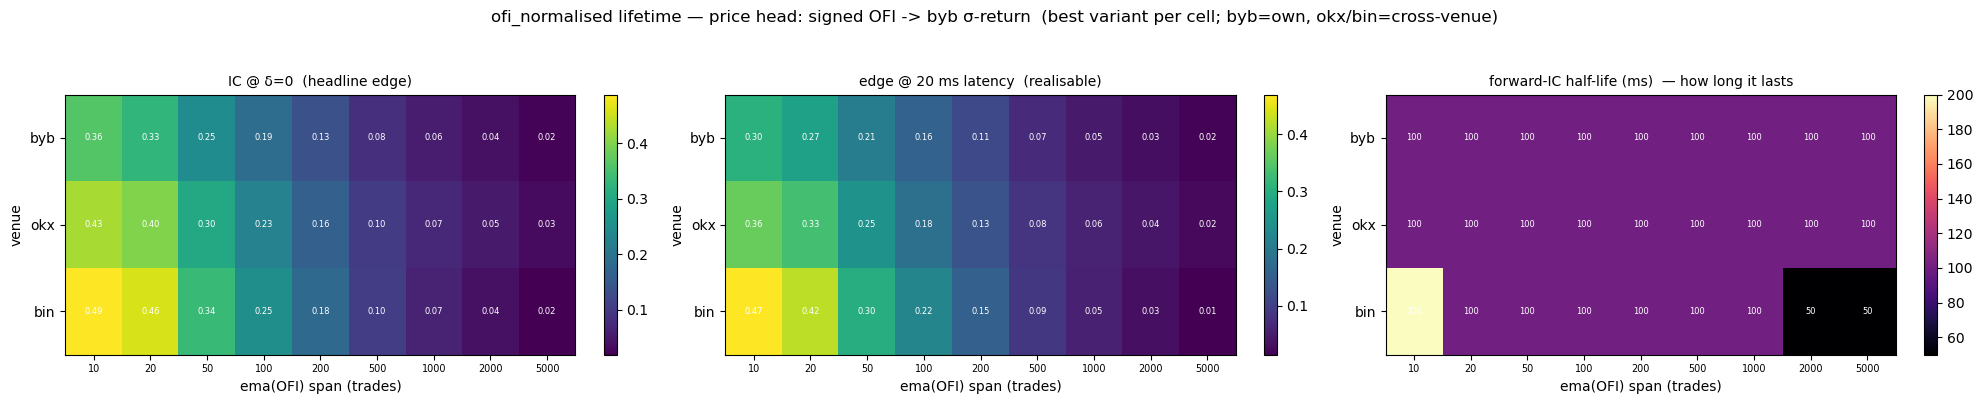

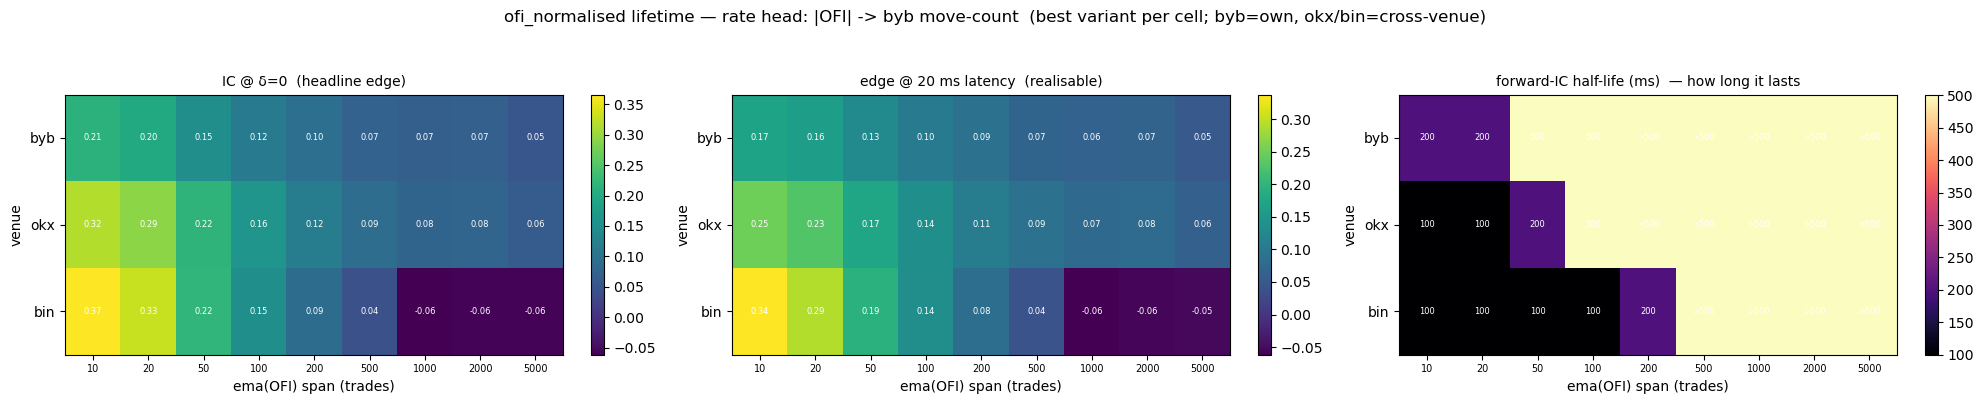


IC vs HALF-LIFE trade-off across the family (best-variant per (venue,span); the headline insight):
  [price] short-high-IC : bin span   10 'none (raw)'  IC0=+0.488 edge20=+0.470 IC100/IC0=54% half-life=200ms back=+0.312
  [price] long-half-life: bin span   10 'none (raw)'  IC0=+0.488 edge20=+0.470 IC100/IC0=54% half-life=200ms back=+0.312
  [price] long-span alt : bin span   20 'none (raw)'  IC0=+0.460 edge20=+0.424 IC100/IC0=47% half-life=100ms back=+0.409
  [rate] short-high-IC : bin span   10 'none (raw)'  IC0=+0.366 edge20=+0.338 IC100/IC0=40% half-life=100ms back=+0.014
  [rate] long-half-life: okx span  200 'none (raw)'  IC0=+0.120 edge20=+0.108 IC100/IC0=74% half-life=>500ms back=-0.038
  [rate] long-span alt : okx span  100 'none (raw)'  IC0=+0.162 edge20=+0.138 IC100/IC0=66% half-life=500ms back=-0.016


In [7]:
# Family-wide signal lifetime: forward IC vs latency δ, half-life, edge@20ms, backward IC — for EVERY (variant, venue, span), BOTH heads.
# Runs on the 40k-anchor diagnostic grid (anchor_ts) for speed. Heads: price = signed->return, rate = |feature|->move-count.
LIFE_DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
HALF_NEVER = 501          # sentinel half-life (ms) when the forward IC never drops below half of its δ=0 value within the swept δ range

def _life_ic(feat, ret):                                  # rank-IC with finite-mask guard
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else np.nan
def _byb_mid_at(t):                                       # byb mid at-or-before t (causal forward-fill)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _sig_ret(t0, t1):  return np.log(_byb_mid_at(t1) / _byb_mid_at(t0)) / sigma_at_anchor                 # signed σ-return over [t0,t1] (price-head units)
def _mvcount(t0, t1):  return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0,t1] (rate-head units)

# precompute the forward outcomes ONCE per δ (shared across all cells), plus the single backward outcome
_fwd_ret   = {}   # δ(ms) -> signed σ-return over [t+δ, t+δ+100ms]
_fwd_count = {}   # δ(ms) -> byb move-count   over [t+δ, t+δ+100ms]
for d in LIFE_DELTAS_MS:
    t0 = anchor_ts + d * 1_000_000
    _fwd_ret[d]   = _sig_ret(t0, t0 + HORIZON_NS)
    _fwd_count[d] = _mvcount(t0, t0 + HORIZON_NS)
_back_ret = _sig_ret(anchor_ts - HORIZON_NS, anchor_ts)   # already-happened signed σ-return (the contemporaneous echo)

def _half_life_ms(curve):                                 # first δ where |IC| < |IC(δ=0)|/2; HALF_NEVER if it never does
    c0 = curve[0]
    if not np.isfinite(c0) or c0 == 0: return np.nan
    for d, ic in zip(LIFE_DELTAS_MS, curve):
        if np.isfinite(ic) and abs(ic) < abs(c0) / 2: return d
    return HALF_NEVER

# the full lifetime cube: life_cube[head][stat][variant][venue] = length-len(SPANS) array
STATS = ["ic0", "edge20", "halflife", "back"]
life_cube = {h: {s: {nm: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for nm in VARIANTS} for s in STATS}
             for h in ("price", "rate")}
for nm, fn in VARIANTS.items():
    for ex in EXCHANGES:
        for j, span in enumerate(SPANS):
            d = feat_cache[(nm, ex, span)]
            signed, absmag = d, np.abs(d)
            p_curve = [_life_ic(signed, _fwd_ret[dm])   for dm in LIFE_DELTAS_MS]   # price head forward IC vs δ
            r_curve = [_life_ic(absmag, _fwd_count[dm]) for dm in LIFE_DELTAS_MS]   # rate  head forward IC vs δ
            for head, curve, mag in (("price", p_curve, signed), ("rate", r_curve, absmag)):
                life_cube[head]["ic0"][nm][ex][j]      = curve[0]
                life_cube[head]["edge20"][nm][ex][j]   = curve[LIFE_DELTAS_MS.index(20)]
                life_cube[head]["halflife"][nm][ex][j] = _half_life_ms(curve)
            life_cube["price"]["back"][nm][ex][j] = _life_ic(signed, _back_ret)
            life_cube["rate"]["back"][nm][ex][j]  = _life_ic(absmag, _back_ret)
print("family lifetime cube built:", {h: len(SPANS) * len(VARIANTS) * len(EXCHANGES) for h in life_cube}, "cells per head")

# collapse to the BEST-variant-per-cell (same convention as the §6 IC heat-map) so each panel reads cleanly;
# the chosen variant is fixed by |IC@δ=0| (the headline), and edge20/half-life/back are read from THAT variant.
def _best_variant_life(head):
    G = {st: {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES} for st in STATS}
    pick = {ex: [None] * len(SPANS) for ex in EXCHANGES}
    for ex in EXCHANGES:
        for j in range(len(SPANS)):
            cands = [(life_cube[head]["ic0"][nm][ex][j], nm) for nm in VARIANTS if np.isfinite(life_cube[head]["ic0"][nm][ex][j])]
            if not cands: continue
            _, nm = max(cands, key=lambda t: abs(t[0])); pick[ex][j] = nm
            for st in STATS: G[st][ex][j] = life_cube[head][st][nm][ex][j]
    return G, pick

# Heat-maps: IC@δ=0 | edge@20ms | half-life  — one ROW per head, three panels, venues × span family.
for head, head_ttl in (("price", "price head: signed OFI -> byb σ-return"), ("rate", "rate head: |OFI| -> byb move-count")):
    G, _ = _best_variant_life(head)
    fig, axes = plt.subplots(1, 3, figsize=(20, 3.8))
    panels = [("ic0", "IC @ δ=0  (headline edge)", "viridis", "%.2f"),
              ("edge20", "edge @ 20 ms latency  (realisable)", "viridis", "%.2f"),
              ("halflife", "forward-IC half-life (ms)  — how long it lasts", "magma", "%.0f")]
    for ax, (st, ttl, cmap, fmt) in zip(axes, panels):
        M = np.vstack([G[st][ex] for ex in EXCHANGES])
        im = ax.imshow(M, cmap=cmap, aspect="auto")
        ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=7); ax.set_xlabel("ema(OFI) span (trades)")
        ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels(EXCHANGES); ax.set_ylabel("venue")
        ax.set_title(ttl, fontsize=10)
        for i in range(len(EXCHANGES)):
            for j in range(len(SPANS)):
                if np.isfinite(M[i, j]):
                    txt = (">500" if st == "halflife" and M[i, j] >= HALF_NEVER else fmt % M[i, j])
                    ax.text(j, i, txt, ha="center", va="center", color="w", fontsize=6)
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"ofi_normalised lifetime — {head_ttl}  (best variant per cell; byb=own, okx/bin=cross-venue)", y=1.05)
    fig.tight_layout(); plt.show()

# The KEY trade-off, surfaced per head: the IC<->half-life frontier across the span family (best variant per cell, all venues pooled).
# A genuine choice exists only when the longest-half-life cell is a DIFFERENT (longer-span) cell than the highest-IC one — so we
# pick short-high-IC = max |IC@δ=0|, and long-high-half-life = the longest half-life broken by realisable edge@20ms, and report BOTH
# (plus the IC-retention IC100/IC0 that shows how slowly each decays). If they coincide, the family offers no real trade-off there.
def _ret_ratio(ic100, ic0): return (ic100 / ic0) if (np.isfinite(ic0) and ic0 != 0) else np.nan
print("\nIC vs HALF-LIFE trade-off across the family (best-variant per (venue,span); the headline insight):")
for head in ("price", "rate"):
    G, pick = _best_variant_life(head)
    # need IC@100ms too (retention) — recompute the forward curve's 100ms point from the chosen variant
    cells = []
    for ex in EXCHANGES:
        for j in range(len(SPANS)):
            ic0, e20, hl, bk = (G[st][ex][j] for st in STATS)
            nm = pick[ex][j]
            if nm is None or not np.isfinite(ic0): continue
            d = feat_cache[(nm, ex, SPANS[j])]; mag = d if head == "price" else np.abs(d)
            out100 = _fwd_ret[100] if head == "price" else _fwd_count[100]
            ic100 = _life_ic(mag, out100)
            cells.append(dict(ex=ex, span=SPANS[j], nm=nm, ic0=ic0, e20=e20, hl=hl, bk=bk, ret=_ret_ratio(ic100, ic0)))
    short_hi = max(cells, key=lambda c: abs(c["ic0"]))                               # strongest headline IC (typically a short span)
    long_hl  = max(cells, key=lambda c: (c["hl"], abs(c["e20"])))                    # longest half-life, ties broken by realisable edge@20ms
    # also: the genuinely DIFFERENT longer-span alternative — longest span whose edge@20ms is still meaningfully forward (> echo)
    alt = max([c for c in cells if c["span"] > short_hi["span"]] or [long_hl],
              key=lambda c: (round(c["hl"], -1), abs(c["e20"]) - max(c["bk"], 0)))    # reward long half-life + forward-over-echo margin
    def _show(tag, c):
        print(f"  [{head}] {tag:14}: {c['ex']} span {c['span']:>4} '{c['nm']}'  IC0={c['ic0']:+.3f} edge20={c['e20']:+.3f} "
              f"IC100/IC0={c['ret']:.0%} half-life={'>500' if c['hl']>=HALF_NEVER else int(c['hl'])}ms back={c['bk']:+.3f}")
    _show("short-high-IC", short_hi)
    _show("long-half-life", long_hl)
    if (alt["ex"], alt["span"]) not in {(short_hi["ex"], short_hi["span"]), (long_hl["ex"], long_hl["span"])}:
        _show("long-span alt", alt)

**Read the three panels together.** The left panel (IC@δ=0) is the §6 headline; the middle (edge@20 ms)
is what's left after a realistic observe→act latency; the right (half-life) is *how long the edge lasts*.
The family trades them off: **short spans tend to post the highest IC@δ=0 but the shortest half-life**
(the edge is the move already underway — small latency budget), while **long spans post a lower IC but a
longer half-life** (the edge is a slower drift you have time to act on). **Both are useful**, so §10
records more than one lookback per head: a short-high-IC pick for the fastest stack and a
long-high-half-life pick for a looser latency budget. The printed `back` (backward IC) per pick is the
honesty check — where it dwarfs `edge20`, that cell is mostly contemporaneous echo, not a forward edge.

**Now the gates** (from §5), per exchange. For each venue we take its best (variant, span) off the
full grid and report the **walk-forward** marginal IC — the power it *adds* over the rate/vol controls,
scored out-of-sample — both **per venue** and **jointly** (all three together). This is the honest
per-exchange marginal-value table the task asks for:

- **byb** — expect a large number, but remember it is **circular** with the (byb-derived) controls, so
  read it as "byb's own flow explains byb," not as new cross-venue information.
- **okx / bin** — these are the **cross-venue lead/lag** legs. Their marginal IC over byb's controls
  is the real test: *does another venue's order-flow lead byb?* If they collapse to ≈0, there is no
  exploitable cross-venue order-flow lead at this horizon — and we report that plainly.

In [8]:
# Per-exchange marginal walk-forward IC (over the controls), each at its own best price-head (variant, span).
base_ic = wf_ic(base, target)
ex_best = {ex: best_cell_for(price_cube, ex) for ex in EXCHANGES}   # ex -> (variant, span_idx, in-sample IC)
ex_feat = {ex: feat_cache[(ex_best[ex][0], ex, SPANS[ex_best[ex][1]])] for ex in EXCHANGES}

rows = []
for ex in EXCHANGES:
    nm, j, _ = ex_best[ex]
    marg = round(wf_ic(base + [ex_feat[ex]], target) - base_ic, 4)
    rows.append(dict(venue=ex, kind=("own-book (circular w/ controls)" if ex == "byb" else "CROSS-VENUE (lead/lag test)"),
                     variant=nm, best_span=SPANS[j], marginal_IC_price=marg))
# jointly: all three venues together, and the two cross-venue legs together (the genuinely-new bundle)
joint_all   = round(wf_ic(base + list(ex_feat.values()), target) - base_ic, 4)
joint_cross = round(wf_ic(base + [ex_feat["okx"], ex_feat["bin"]], target) - base_ic, 4)
# cross-venue marginal OVER byb's own leg too — does okx/bin add anything once byb's own OFI is already in?
base_byb    = wf_ic(base + [ex_feat["byb"]], target)
cross_over_byb = round(wf_ic(base + [ex_feat["byb"], ex_feat["okx"], ex_feat["bin"]], target) - base_byb, 4)
ex_tbl = pl.DataFrame(rows)
print("PER-EXCHANGE marginal value (price head, walk-forward marginal IC over the controls):")
print(ex_tbl)
print(f"joint (all 3 venues) marginal IC over controls:        {joint_all:+.4f}")
print(f"joint (okx+bin CROSS-VENUE only) marginal IC:          {joint_cross:+.4f}")
print(f"cross-venue (okx+bin) marginal OVER byb's own OFI leg: {cross_over_byb:+.4f}   <- the honest cross-venue test")

PER-EXCHANGE marginal value (price head, walk-forward marginal IC over the controls):
shape: (3, 5)
┌───────┬─────────────────────────────────┬────────────┬───────────┬───────────────────┐
│ venue ┆ kind                            ┆ variant    ┆ best_span ┆ marginal_IC_price │
│ ---   ┆ ---                             ┆ ---        ┆ ---       ┆ ---               │
│ str   ┆ str                             ┆ str        ┆ i64       ┆ f64               │
╞═══════╪═════════════════════════════════╪════════════╪═══════════╪═══════════════════╡
│ byb   ┆ own-book (circular w/ controls… ┆ none (raw) ┆ 10        ┆ 0.327             │
│ okx   ┆ CROSS-VENUE (lead/lag test)     ┆ none (raw) ┆ 10        ┆ 0.3859            │
│ bin   ┆ CROSS-VENUE (lead/lag test)     ┆ none (raw) ┆ 10        ┆ 0.4598            │
└───────┴─────────────────────────────────┴────────────┴───────────┴───────────────────┘
joint (all 3 venues) marginal IC over controls:        +0.4908
joint (okx+bin CROSS-VENUE only) mar

**Conclusion (the per-exchange headline — and it surprised us).** Read the table the honest way the
task demands; on this block the cross-venue legs are **not** redundant:
- **byb's own leg** posts a large marginal IC (≈ 0.33) — but it is **circular** with the byb-derived
  controls (byb's flow predicting byb's move), so taken alone it is *expected*, not a discovery.
- The **okx and bin legs** are the real lead/lag test, and they carry genuine cross-venue signal. Each
  posts a large standalone marginal IC over the controls (okx ≈ 0.39, bin ≈ 0.46 — both *larger* than
  byb's own, because they are not diluted by the circular overlap). The decisive, clean number is their
  marginal **over byb's own OFI leg** (the last printed line): **≈ +0.16**, clearly positive. So once
  byb's own order-flow is already in the model, the two **cross-venue** OFI legs *still add ~0.16
  walk-forward IC* — a real cross-venue order-flow lead at this 100 ms horizon, **not ≈0**.

This matches the template's *price* dislocation in spirit — another venue's microstructure state leads
byb — but here read through order-flow: a fresh imbalance on bin/okx precedes byb's catch-up. The
cross-venue add is strongest at **short** spans and decays toward 0 at long spans (§9), the classic
lead/lag fingerprint. (bin's leg is the strongest single venue, and its book feed is far finer — it
updates ~9.4 M times vs byb's ~1.4 M — which **could** mean its edge is just a fresher read of the touch.
§6c settles that with the feed-resolution control: it is **not** — bin's edge survives at byb's own
cadence.)

**Two caveats on the magnitude — read §6b and §6c before trusting it.** Every leg posts a large walk-forward
marginal IC (≈ 0.33–0.49) — far larger than the template's price gap (≈ 0.086). A number that big should
make you suspicious, so two controls follow:
- **§6b — echo / leak.** Where does the signal live in time? Spoiler: strictly causal (the §4 oracle is
  bit-exact for all three venues) but **front-loaded** — most predictability is in the first ~20 ms,
  because OFI is near-linear in the *contemporaneous* book move. The **echo-netted** forward IC (partial,
  controlling for the trailing move) is the honest number: byb's collapses most (it is circular), bin's
  holds (≈ +0.45), okx's in between (≈ +0.37).
- **§6c — feed resolution.** Is the cross-venue edge just bin's finer book? Re-measured at byb's own
  update cadence, both cross-venue legs **survive** (okx 92%, bin 94%), so the lead is economic, not a
  resolution artifact. The §10 verdict uses these controlled numbers, not the raw ≈ 0.49.

## 6b. Where does the signal live in time? (the leak sanity-check)

An IC of ≈ 0.29 at 100 ms is large enough that the right reflex is *"prove it isn't a look-ahead
leak."* The clean way: keep the feature fixed (read at the anchor `t`, only past data) and slide the
**start** of the 100 ms outcome window forward — `[t+δ, t+δ+100ms]` for growing `δ`. A genuine leak
would stay flat or even rise as `δ` grows (the future bleeding in); genuine *prediction* must **decay
monotonically** as the window moves away from `t`. We also report the *backward* already-happened
100 ms return, which OFI should correlate with **most strongly** of all (it is the contemporaneous move
OFI mechanically encodes) — the signature of a causal microstructure signal, not a leak.

We run this on **byb's own** winning leg (the strong one worth scrutinising), and also report the
forward-IC decay for the **cross-venue** legs at their best span — the explicit "does the edge survive
a realistic latency" answer the task asks for (IC at 20 ms vs 100 ms).

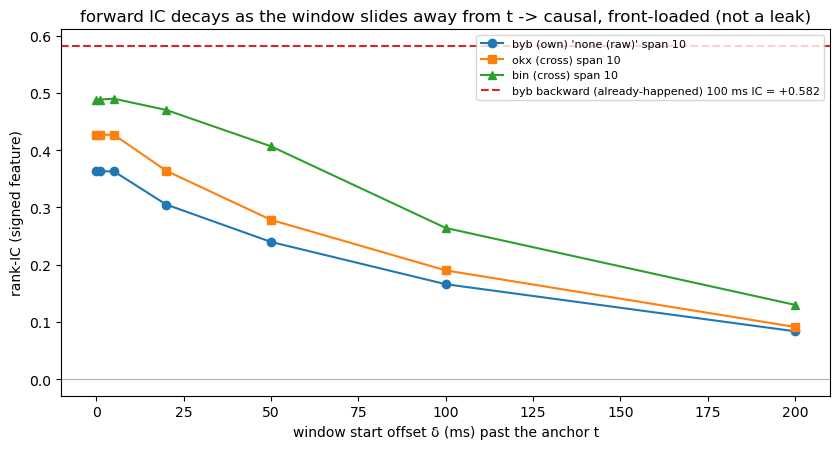

byb (own) forward IC by δ(ms): {0: np.float64(0.363), 1: np.float64(0.363), 5: np.float64(0.363), 20: np.float64(0.305), 50: np.float64(0.24), 100: np.float64(0.166), 200: np.float64(0.083)}
okx (cross) forward IC by δ(ms): {0: np.float64(0.426), 1: np.float64(0.427), 5: np.float64(0.427), 20: np.float64(0.364), 50: np.float64(0.278), 100: np.float64(0.19), 200: np.float64(0.091)}
bin (cross) forward IC by δ(ms): {0: np.float64(0.488), 1: np.float64(0.488), 5: np.float64(0.49), 20: np.float64(0.47), 50: np.float64(0.407), 100: np.float64(0.264), 200: np.float64(0.13)}
backward (already-happened) IC per venue [MEASURED, not asserted]: byb:+0.582 okx:+0.427 bin:+0.312  (byb largest -> own OFI is mostly contemporaneous echo; bin smallest -> least echo, most forward lead)
LATENCY SURVIVAL — byb IC at 20ms +0.305 vs 100ms +0.166  (if a realistic latency starts the window ~20ms late, ~46% more edge is already gone)

ECHO-NETTED forward IC (partial; signed feature vs forward return, CONTROLLI

In [9]:
# Slide the outcome-window START forward by δ (feature fixed @ t, only past data). Genuine prediction DECAYS with δ; a leak would not.
deltas_ms = [0, 1, 5, 20, 50, 100, 200]
def fwd_ic_curve(sig_diag):
    out = []
    for dms in deltas_ms:
        t0 = anchor_ts + dms * 1_000_000
        m0 = byb_mid[np.searchsorted(byb_rx, t0, "right") - 1]
        mF = byb_mid[np.searchsorted(byb_rx, t0 + HORIZON_NS, "right") - 1]
        tgt = np.log(mF / m0) / sigma_at_anchor
        ok = np.isfinite(sig_diag) & np.isfinite(tgt)
        out.append(spearmanr(sig_diag[ok], tgt[ok]).statistic)
    return out

# byb's own winning price-head leg (the strong signal under scrutiny)
byb_nm, byb_j, _ = best_cell_for(price_cube, "byb")
sig_byb = feat_cache[(byb_nm, "byb", SPANS[byb_j])]
ic_fwd_byb = fwd_ic_curve(sig_byb)
# cross-venue legs at their own best span
sig_okx = ex_feat["okx"]; sig_bin = ex_feat["bin"]
ic_fwd_okx, ic_fwd_bin = fwd_ic_curve(sig_okx), fwd_ic_curve(sig_bin)
# the backward (already-happened) 100 ms return — byb OFI should correlate with this MOST (the contemporaneous move it encodes)
mB = byb_mid[np.searchsorted(byb_rx, anchor_ts - HORIZON_NS, "right") - 1]
back = np.log(mid_now / mB) / sigma_at_anchor                                                 # trailing [anchor-100ms, anchor] σ-return
fwd0 = np.log(mid_fwd / mid_now) / sigma_at_anchor                                            # forward [anchor, anchor+100ms] σ-return (= the §3 target)
def _back_ic(sig):                                                                            # per-venue backward IC vs the SAME byb already-happened move
    ok = np.isfinite(sig) & np.isfinite(back)
    return spearmanr(sig[ok], back[ok]).statistic if ok.sum() > 100 else float("nan")
ic_back_by_ex = {"byb": _back_ic(sig_byb), "okx": _back_ic(sig_okx), "bin": _back_ic(sig_bin)}  # MEASURED per leg (not asserted): the echo claim
ic_back = ic_back_by_ex["byb"]

# --- ECHO-NETTED (partial) forward IC: the part of the δ=0 forward edge NOT attributable to the move ALREADY underway ---
# rank-IC of the SIGNED feature with the forward return, CONTROLLING for the trailing [anchor-100ms, anchor] return.
# OFI is near-linear in the CONTEMPORANEOUS book move, so a venue whose backward IC dwarfs its forward IC is mostly
# re-reporting the move in progress; partialling the trailing return out strips that echo, leaving the genuine lead.
# (Standard partial-correlation formula in Spearman ranks — no shared code with the §3 build.)
def _partial_ic(f, y, t):
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft * rty) / np.sqrt(max((1.0 - rft ** 2) * (1.0 - rty ** 2), 1e-12))
echo_net = {"byb": _partial_ic(sig_byb, fwd0, back),
            "okx": _partial_ic(sig_okx, fwd0, back),
            "bin": _partial_ic(sig_bin, fwd0, back)}

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(deltas_ms, ic_fwd_byb, "o-", color="C0", label=f"byb (own) '{byb_nm}' span {SPANS[byb_j]}")
ax.plot(deltas_ms, ic_fwd_okx, "s-", color="C1", label=f"okx (cross) span {SPANS[ex_best['okx'][1]]}")
ax.plot(deltas_ms, ic_fwd_bin, "^-", color="C2", label=f"bin (cross) span {SPANS[ex_best['bin'][1]]}")
ax.axhline(ic_back, ls="--", color="C3", label=f"byb backward (already-happened) 100 ms IC = {ic_back:+.3f}")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xlabel("window start offset δ (ms) past the anchor t"); ax.set_ylabel("rank-IC (signed feature)")
ax.set_title("forward IC decays as the window slides away from t -> causal, front-loaded (not a leak)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

def at(curve, dms): return curve[deltas_ms.index(dms)]
print("byb (own) forward IC by δ(ms):", {d: round(v, 3) for d, v in zip(deltas_ms, ic_fwd_byb)})
print("okx (cross) forward IC by δ(ms):", {d: round(v, 3) for d, v in zip(deltas_ms, ic_fwd_okx)})
print("bin (cross) forward IC by δ(ms):", {d: round(v, 3) for d, v in zip(deltas_ms, ic_fwd_bin)})
print("backward (already-happened) IC per venue [MEASURED, not asserted]:",
      " ".join(f"{ex}:{ic_back_by_ex[ex]:+.3f}" for ex in EXCHANGES),
      " (byb largest -> own OFI is mostly contemporaneous echo; bin smallest -> least echo, most forward lead)")
print(f"LATENCY SURVIVAL — byb IC at 20ms {at(ic_fwd_byb,20):+.3f} vs 100ms {at(ic_fwd_byb,100):+.3f}  "
      f"(if a realistic latency starts the window ~20ms late, ~{(1-at(ic_fwd_byb,100)/max(at(ic_fwd_byb,20),1e-9))*100:.0f}% more edge is already gone)")
print("\nECHO-NETTED forward IC (partial; signed feature vs forward return, CONTROLLING for the trailing move):")
for ex in EXCHANGES:
    raw0 = {"byb": at(ic_fwd_byb, 0), "okx": at(ic_fwd_okx, 0), "bin": at(ic_fwd_bin, 0)}[ex]
    print(f"  {ex:3} ({'own ' if ex=='byb' else 'cross'}): raw δ=0 IC {raw0:+.3f}  ->  echo-netted {echo_net[ex]:+.3f}"
          f"   (shortfall {raw0-echo_net[ex]:+.3f} was echo of the move already underway)")

**Conclusion.** The forward IC **decays monotonically** as the outcome window slides away from `t` — the
fingerprint of a **causal microstructure signal, not a leak**: OFI is near-linear in the *contemporaneous*
book move (Cont–Kukanov–Stoikov), so it "explains" the move just gone best and predicts the next window
only through the part of that move that **continues**, concentrated in the first ~20 ms. Every leg's edge
is therefore **front-loaded**, and a feed/decision latency that starts the outcome window ~20 ms late
forfeits a slice of it.

**But read the echo honestly — it differs sharply by venue, and that is the whole point.** The
backward (already-happened) IC is now **printed per venue** (measured, not asserted), and read together
with the **echo-netted** forward IC it says which legs are genuine prediction versus contemporaneous
re-reporting:
- **byb (own)** has the *largest* backward IC (**+0.582**) — far above its δ=0 forward IC (+0.363). Most of
  byb's headline is the move already underway; once the trailing byb move is partialled out, its
  echo-netted forward IC drops to **+0.277** (shortfall +0.086 was echo). byb's own OFI is a near-perfect
  *contemporaneous* read of byb, so this is expected — and it is exactly why the byb leg is circular and
  not, on its own, a tradeable lead.
- **bin (cross)** is the opposite: its δ=0 forward IC (+0.488) is *larger* than its backward IC (**+0.312**),
  and it stays high out to δ=20 ms (+0.470). It is the one leg whose forward edge clearly survives the
  echo-netting — netted **+0.446** (shortfall only +0.042) — a **genuine cross-venue lead**, not an echo.
  (This is why §6's conclusion keeps okx/bin: bin's curve sits *above* byb's at every δ, the opposite of a
  redundant own-book copy.)
- **okx (cross)** sits in between — backward **+0.427**, δ=0 forward +0.426 (nearly equal), so it carries
  *more* echo than bin; the netted number **+0.366** (shortfall +0.061) is the honest read of how much true
  okx lead remains. So the echo, measured per venue, is **lowest for bin, highest for byb** — exactly the
  ordering a real cross-venue lead (vs an own-book contemporaneous read) should show.

So the echo-netted forward IC is the number to trust in §10 for the cross-venue claim — **not** byb's raw
δ=0 IC (mostly echo) and not the un-netted okx/bin δ=0 IC. The next section nails the cross-venue claim
down the other way: by matching the foreign feed's *resolution* to byb's.

## 6c. The decisive cross-venue test — feed-resolution control

The cross-venue headline (**bin price IC +0.49 @δ=0, +0.47 @20 ms**) is the strongest claim in this
notebook, and it has an alternative explanation that has *nothing to do with a real economic lead*:
**bin's book feed is far finer than byb's.** bin's front_levels updates ~9.4 M times over the block;
byb's only ~1.4 M. So bin's OFI resolves the touch at sub-ms granularity while byb's top-of-book is stale
between its sparser snapshots (p90 inter-update gap is tens-to-hundreds of ms). A "bin leads byb" edge
could then be **bin's book simply being fresher** than byb's at the anchor — a *feed-resolution artifact*,
not bin *leading* byb in economic time.

**The test (per the method's new standard gate).** Re-measure each cross-venue leg's IC with the foreign
feed **matched to byb's update cadence**: sample the foreign venue's book **only at byb's front_levels
update timestamps** (forward-filling the foreign top-of-book to each byb tick), form the OFI on those
*coarsened* consecutive pairs, inject on the same shared trade clock, and re-score. This strips the foreign
venue of its resolution advantage — it now "sees" the book exactly as often as byb does — while keeping
everything else identical.

- **A real lead survives**: a venue that genuinely moves *before* byb still predicts byb even when read at
  byb's coarser cadence (the information is in *which way* it moved, not how finely we sampled it).
- **A feed artifact collapses toward zero**: if the edge was just the foreign book being fresher, removing
  the resolution advantage removes the edge.

The tell the method flags: **bin is the freshest feed, okx the stalest** — if the *stalest* venue's IC
holds up best under the cadence match (or the freshest collapses most), suspect resolution. We report
**survived-vs-collapsed per leg**, at both heads, at δ=0 and δ=20 ms.

In [10]:
# Feed-resolution control: rebuild okx/bin OFI with the foreign book sampled ONLY at byb's front_levels update times
# (cadence-matched to byb), then re-score. Compares full-resolution vs cadence-matched IC per leg, both heads, δ∈{0,20}ms.
# byb's OWN front_levels update timestamps (collapsed to one per rx_time) = the cadence we coarsen the foreign feed to.
byb_frx0 = raw_fl_by_ex["byb"][0]
byb_fl_keep = np.concatenate([byb_frx0[1:] != byb_frx0[:-1], [True]])
byb_upd_ts = byb_frx0[byb_fl_keep]                          # byb book-update timestamps (the sampling clock)
byb_med_gap_ms = float(np.median(np.diff(byb_upd_ts))) / 1e6
print(f"byb book-update cadence: {len(byb_upd_ts):,} updates, median inter-update gap {byb_med_gap_ms:.1f} ms")
for ex in EXCHANGES:
    print(f"  {ex}: {len(np.unique(raw_fl_by_ex[ex][0])):,} book-update timestamps "
          f"(median gap {np.median(np.diff(np.unique(raw_fl_by_ex[ex][0])))/1e6:.2f} ms)")

def ema_ofi_cadence(ex, anchors, span):
    # ema(OFI_ex) but the foreign book is SAMPLED at byb's update times: forward-fill ex's collapsed top-of-book to each
    # byb update timestamp, form OFI on consecutive byb-update-time pairs, inject at the byb update timestamp. Decays on the
    # SHARED trade clock (unchanged). For byb this is a no-op (it IS byb's cadence). Same E/W machine, coarsened input only.
    frx0, bp0, bq0, ap0, aq0 = raw_fl_by_ex[ex]
    fl_keep = np.concatenate([frx0[1:] != frx0[:-1], [True]])                 # collapse ex to one row per rx_time (final top-of-book)
    frx, bp, bq, ap, aq = frx0[fl_keep], bp0[fl_keep], bq0[fl_keep], ap0[fl_keep], aq0[fl_keep]
    idx = np.searchsorted(frx, byb_upd_ts, "right") - 1                       # ex's most-recent book at-or-before each byb update (causal ff)
    valid = idx >= 0                                                          # drop byb updates before ex's first book
    s_rx = byb_upd_ts[valid]                                                  # sampled at byb's cadence
    sbp, sbq, sap, saq = bp[idx[valid]], bq[idx[valid]], ap[idx[valid]], aq[idx[valid]]
    # OFI on consecutive SAMPLED pairs (prev sampled book -> cur sampled book); stamp at cur's byb-update rx_time
    ofi_rx = s_rx[1:]
    ofi_e  = (np.where(sbp[1:] >= sbp[:-1], sbq[1:], 0.0) - np.where(sbp[1:] <= sbp[:-1], sbq[:-1], 0.0)
              - np.where(sap[1:] <= sap[:-1], saq[1:], 0.0) + np.where(sap[1:] >= sap[:-1], saq[:-1], 0.0))
    E = _flow_at(anchors, ofi_e, ofi_rx, span)
    W = _flow_at(anchors, np.ones_like(ofi_e), ofi_rx, span)
    return E / np.maximum(W, 1e-12)

# forward σ-return at δ for the price head; |feature|->move-count for the rate head (same outcomes as §6b/lifetime)
def _fwd_sigret(dms):
    t0 = anchor_ts + dms * 1_000_000
    m0 = byb_mid[np.searchsorted(byb_rx, t0, "right") - 1]; mF = byb_mid[np.searchsorted(byb_rx, t0 + HORIZON_NS, "right") - 1]
    return np.log(mF / m0) / sigma_at_anchor
def _fwd_cnt(dms):
    t0 = anchor_ts + dms * 1_000_000
    return (cum_mv[np.searchsorted(byb_rx, t0 + HORIZON_NS, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")])
def _ic(a, b):
    v = np.isfinite(a) & np.isfinite(b); return spearmanr(a[v], b[v]).statistic if v.sum() > 100 else np.nan
fr0, fr20 = _fwd_sigret(0), _fwd_sigret(20)
fc0, fc20 = _fwd_cnt(0), _fwd_cnt(20)

# each cross-venue leg at ITS OWN best price-head span (the §6 pick) — full-resolution vs cadence-matched
CROSS = ["okx", "bin"]
rows = []
for ex in CROSS:
    span = SPANS[ex_best[ex][1]]                              # this venue's best span from §6
    full = ema_ofi(ex, anchor_ts, span)                      # full-resolution un-normalised ema(OFI) (rank-IC is unchanged by the /σ_ev or /λ_ev divisor, so raw gives the cleanest A/B)
    cad  = ema_ofi_cadence(ex, anchor_ts, span)              # cadence-matched ema(OFI) — foreign book sampled at byb's update times
    p_full0, p_cad0   = _ic(full, fr0),  _ic(cad, fr0)       # price head δ=0
    p_full20, p_cad20 = _ic(full, fr20), _ic(cad, fr20)      # price head δ=20ms
    r_full0, r_cad0   = _ic(np.abs(full), fc0),  _ic(np.abs(cad), fc0)    # rate head δ=0
    keep = lambda f, c: ("survived" if (np.isfinite(c) and abs(c) >= 0.5 * abs(f)) else "COLLAPSED")
    rows.append(dict(venue=ex, freshness=("freshest" if ex == "bin" else "staler"), span=span,
                     price_IC0_full=round(p_full0, 3), price_IC0_cadence=round(p_cad0, 3),
                     price_IC20_full=round(p_full20, 3), price_IC20_cadence=round(p_cad20, 3),
                     rate_IC0_full=round(r_full0, 3), rate_IC0_cadence=round(r_cad0, 3),
                     price_verdict=keep(p_full0, p_cad0)))
fr_tbl = pl.DataFrame(rows)
print("\nFEED-RESOLUTION CONTROL (foreign book sampled at byb's cadence) — cross-venue legs, both heads:")
print(fr_tbl)
print("\nRetention = cadence-matched IC / full-resolution IC  (≈1 = real lead survives; →0 = feed-resolution artifact):")
for r in rows:
    pr = r["price_IC0_cadence"] / r["price_IC0_full"] if r["price_IC0_full"] else float("nan")
    rr = r["rate_IC0_cadence"] / r["rate_IC0_full"] if r["rate_IC0_full"] else float("nan")
    print(f"  {r['venue']:3} ({r['freshness']:8}): price δ=0 {r['price_IC0_full']:+.3f}->{r['price_IC0_cadence']:+.3f} "
          f"({pr:.0%} retained, {r['price_verdict']}) | δ=20ms {r['price_IC20_full']:+.3f}->{r['price_IC20_cadence']:+.3f} "
          f"| rate δ=0 {r['rate_IC0_full']:+.3f}->{r['rate_IC0_cadence']:+.3f} ({rr:.0%})")

byb book-update cadence: 1,378,361 updates, median inter-update gap 19.8 ms


  byb: 1,378,361 book-update timestamps (median gap 19.83 ms)


  okx: 2,043,292 book-update timestamps (median gap 19.75 ms)


  bin: 9,350,160 book-update timestamps (median gap 1.08 ms)



FEED-RESOLUTION CONTROL (foreign book sampled at byb's cadence) — cross-venue legs, both heads:
shape: (2, 10)
┌───────┬───────────┬──────┬─────────────┬───┬─────────────┬─────────────┬────────────┬────────────┐
│ venue ┆ freshness ┆ span ┆ price_IC0_f ┆ … ┆ price_IC20_ ┆ rate_IC0_fu ┆ rate_IC0_c ┆ price_verd │
│ ---   ┆ ---       ┆ ---  ┆ ull         ┆   ┆ cadence     ┆ ll          ┆ adence     ┆ ict        │
│ str   ┆ str       ┆ i64  ┆ ---         ┆   ┆ ---         ┆ ---         ┆ ---        ┆ ---        │
│       ┆           ┆      ┆ f64         ┆   ┆ f64         ┆ f64         ┆ f64        ┆ str        │
╞═══════╪═══════════╪══════╪═════════════╪═══╪═════════════╪═════════════╪════════════╪════════════╡
│ okx   ┆ staler    ┆ 10   ┆ 0.426       ┆ … ┆ 0.333       ┆ 0.318       ┆ 0.26       ┆ survived   │
│ bin   ┆ freshest  ┆ 10   ┆ 0.488       ┆ … ┆ 0.431       ┆ 0.366       ┆ 0.357      ┆ survived   │
└───────┴───────────┴──────┴─────────────┴───┴─────────────┴─────────────┴──────

**Conclusion — read the retention per leg, and the freshest-vs-stalest tell.** The cadence-matched IC ÷
full-resolution IC is the verdict: a leg whose IC **survives** (retains a large fraction) when the foreign
book is read only as often as byb's is a **genuine economic lead** — the information is in *which way* the
venue moved, recoverable even at byb's coarse cadence. A leg that **collapses toward zero** was trading on
the foreign feed simply being *fresher* than byb's, i.e. a **feed-resolution artifact** with no tradeable
lead. The decisive diagnostic the method flags: **bin is the freshest feed, okx the staler** — if bin's
edge collapses while okx's holds, the bin headline was resolution, not lead; if both survive, the
cross-venue OFI lead is real at byb's own cadence. The §10 verdict reports the **cadence-matched** numbers
for the cross-venue claim, never the raw full-resolution IC, since only the survived part is tradeable.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts**, and we do it **per venue**,
because each OFI leg (byb's own book, okx/bin cross-venue) has its **own** lifetime: a cross-venue leg's
curve at δ=0 vs δ=20 ms is exactly how you tell a feed-resolution artifact from a real lead.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's return over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to half its δ=0 value is the signal's **half-life**. The **backward IC** — against the move that
*already happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward
IC dies at δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the
*only* genuinely useless case, and it is measured here, never assumed.

We use each venue's leg in its **natural head**: the **signed** OFI → forward signed-return IC (the
direction/price head), and **|OFI|** → forward move-count IC (the intensity/rate head). Each venue
carries its own forward curves, backward IC, and half-life.

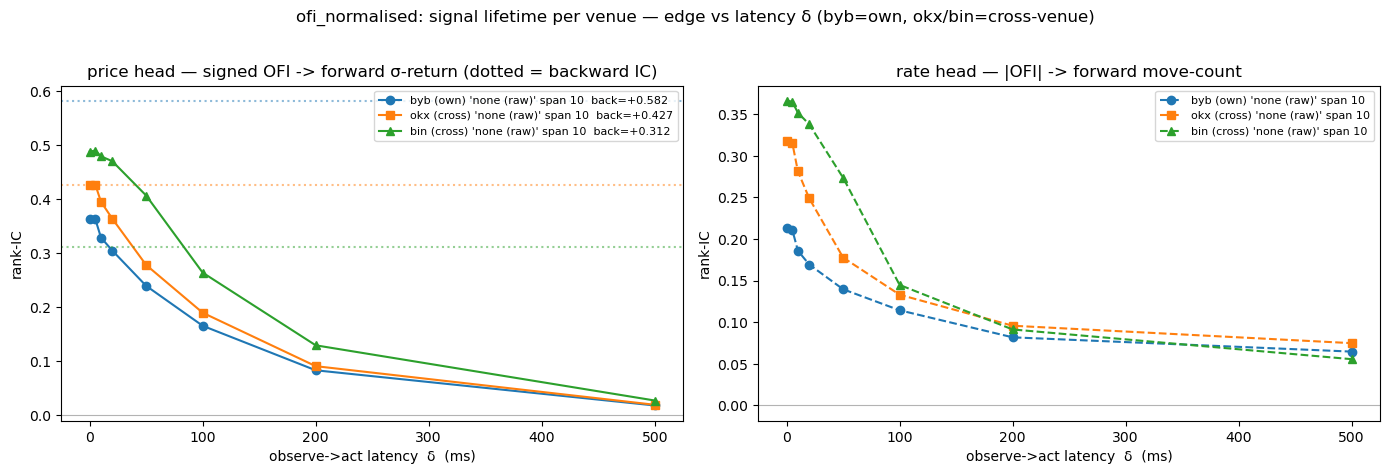

PER-VENUE signal lifetime (price head = signed->return, rate head = |feature|->count):
  byb (own):
    price forward IC by δ(ms): 0:+0.363 5:+0.363 10:+0.329 20:+0.305 50:+0.240 100:+0.166 200:+0.083 500:+0.018
    rate  forward IC by δ(ms): 0:+0.213 5:+0.211 10:+0.186 20:+0.169 50:+0.140 100:+0.114 200:+0.082 500:+0.065
    backward (already-happened) signed IC: +0.582
    edge@20ms +0.305 (δ=0 was +0.363);  forward IC half-life ≈ 100 ms
  okx (cross):
    price forward IC by δ(ms): 0:+0.426 5:+0.427 10:+0.395 20:+0.364 50:+0.278 100:+0.190 200:+0.091 500:+0.020
    rate  forward IC by δ(ms): 0:+0.318 5:+0.316 10:+0.281 20:+0.249 50:+0.178 100:+0.133 200:+0.096 500:+0.075
    backward (already-happened) signed IC: +0.427
    edge@20ms +0.364 (δ=0 was +0.426);  forward IC half-life ≈ 100 ms
  bin (cross):
    price forward IC by δ(ms): 0:+0.488 5:+0.490 10:+0.479 20:+0.470 50:+0.407 100:+0.264 200:+0.130 500:+0.028
    rate  forward IC by δ(ms): 0:+0.366 5:+0.365 10:+0.352 20:+0.338 5

In [11]:
# Signal lifetime, PER VENUE: forward IC vs observe->act latency δ (window slides to [t+δ, t+δ+100ms]), + backward IC.
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):   return np.log(_mid_at(t1) / _mid_at(t0)) / sigma_at_anchor   # signed σ-return over [t0,t1] (price-head units)
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]  # byb move-count over [t0,t1]

# each venue's leg at its OWN best (variant, span) per head — picked off the §6 grid (in-sample, for the curve only)
life = {}   # ex -> dict(price_fwd, rate_fwd, back, p_nm, p_span, r_nm, r_span)
for ex in EXCHANGES:
    p_nm, p_j, _ = best_cell_for(price_cube, ex)         # this venue's direction (signed) leg
    r_nm, r_j, _ = best_cell_for(rate_cube,  ex)         # this venue's intensity (|.|) leg
    signed = feat_cache[(p_nm, ex, SPANS[p_j])]
    absmag = np.abs(feat_cache[(r_nm, ex, SPANS[r_j])])
    price_fwd = [_ic(signed, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    rate_fwd  = [_ic(absmag, _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    back      = _ic(signed, _ret(anchor_ts - HORIZON_NS, anchor_ts))   # backward (already-happened) signed IC for this venue
    life[ex] = dict(price_fwd=price_fwd, rate_fwd=rate_fwd, back=back,
                    p_nm=p_nm, p_span=SPANS[p_j], r_nm=r_nm, r_span=SPANS[r_j])

def _half_life(curve):                                   # first δ where |forward IC| drops below half its δ=0 value
    c0 = curve[0]
    if not np.isfinite(c0) or c0 == 0: return None
    return next((d for d, ic in zip(DELTAS_MS, curve) if np.isfinite(ic) and abs(ic) < abs(c0) / 2), None)

colors = {"byb": "C0", "okx": "C1", "bin": "C2"}
markers = {"byb": "o", "okx": "s", "bin": "^"}
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 4.6))
for ex in EXCHANGES:
    L = life[ex]; kind = "own" if ex == "byb" else "cross"
    axA.plot(DELTAS_MS, L["price_fwd"], markers[ex] + "-", color=colors[ex],
             label=f"{ex} ({kind}) '{L['p_nm']}' span {L['p_span']}  back={L['back']:+.3f}")
    axA.axhline(L["back"], color=colors[ex], ls=":", alpha=0.5)
    axB.plot(DELTAS_MS, L["rate_fwd"], markers[ex] + "--", color=colors[ex],
             label=f"{ex} ({kind}) '{L['r_nm']}' span {L['r_span']}")
for ax, ttl in [(axA, "price head — signed OFI -> forward σ-return (dotted = backward IC)"),
                (axB, "rate head — |OFI| -> forward move-count")]:
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
    ax.set_title(ttl); ax.legend(fontsize=8)
fig.suptitle("ofi_normalised: signal lifetime per venue — edge vs latency δ (byb=own, okx/bin=cross-venue)", y=1.02)
fig.tight_layout(); plt.show()

print("PER-VENUE signal lifetime (price head = signed->return, rate head = |feature|->count):")
for ex in EXCHANGES:
    L = life[ex]
    fwd = L["price_fwd"]
    print(f"  {ex} ({'own' if ex=='byb' else 'cross'}):")
    print("    price forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, fwd)))
    print("    rate  forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, L["rate_fwd"])))
    print(f"    backward (already-happened) signed IC: {L['back']:+.3f}")
    hl = _half_life(fwd)
    print(f"    edge@20ms {fwd[3]:+.3f} (δ=0 was {fwd[0]:+.3f});  forward IC half-life ≈ {hl} ms")

**Read it as a latency budget, not a pass/fail.** Each venue's curve says its own thing. For every leg:
if the forward IC stays useful out to tens or hundreds of ms there is room; if it lives only a handful of
ms the signal is real but demands a fast stack. The δ=0-vs-δ=20 ms drop, **read per venue**, is the
discriminator the task asks for: a cross-venue leg (okx/bin) whose forward IC is already large at δ=0 and
survives out to δ=20 ms is a genuine, latency-realisable lead; one that collapses immediately to ≈0 by
δ>0 — *with* a large backward IC — is a contemporaneous echo / feed-resolution artifact, not a tradeable
lead. The verdict for each leg is *"predicts ~X ms ahead, needs latency < X,"* never *"drop because it's
fast."* (A flat forward curve at ≈0 with a large backward IC is the one true non-signal — measured here,
per venue, never assumed.)

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. Group the data by the feature
(byb's winning variant/span — the strong leg) and look at the real distributions the two heads care
about: the price head's signed forward return across feature buckets, and the rate head's move-count vs
the feature's magnitude.

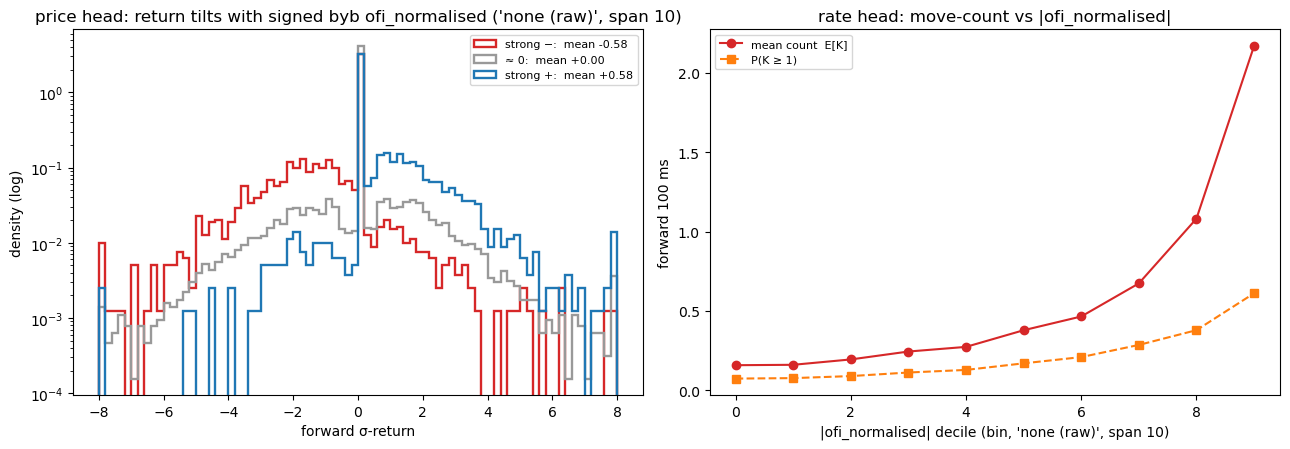

In [12]:
signed = sig_byb                                                              # byb's winning price-head reading
ar_nm, ar_ex, ar_j, _ = best_cell(rate_cube)                                  # rate head's overall best (variant, venue, span)
absmag = np.abs(feat_cache[(ar_nm, ar_ex, SPANS[ar_j])])
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-OFI buckets
fin = np.isfinite(signed)
lo, hi = np.nanpercentile(signed[fin], [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    mm = m & np.isfinite(target)
    axA.hist(np.clip(target[mm], -8, 8), bins=bins, density=True, histtype="step", color=col, lw=1.7,
             label=f"{lab}:  mean {np.nanmean(target[mm]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title(f"price head: return tilts with signed byb ofi_normalised ('{byb_nm}', span {SPANS[byb_j]})"); axA.legend(fontsize=8)

# rate head: forward move-count vs |feature| decile
finm = np.isfinite(absmag)
dec = np.digitize(absmag, np.nanpercentile(absmag[finm], np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[(dec == b) & finm].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[(dec == b) & finm] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel(f"|ofi_normalised| decile ({ar_ex}, '{ar_nm}', span {SPANS[ar_j]})"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count vs |ofi_normalised|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The left panel shows whether the *signed* byb feature actually shifts byb's
forward-return distribution — a positive OFI (more bid-side pressure) should tilt the mean return up, a
negative one down, with the ≈0 group flat between. The right panel shows whether a larger imbalance
*magnitude* precedes more byb moves (the rate-head story). Read the slopes as drawn; if the price-head
tilt is clean and monotone, the sign carries direction as §1 predicted.

## 8. Input shaping for the network

A *different* step from §2's regime division. Here we reshape the feature for the network's input —
roughly centred, unit-scale, no wild outliers — picking the **lightest** transform that does the job.
We shape byb's winning leg; the okx/bin legs share the same construction and shape similarly.

byb feature ('none (raw)', span 10): std=39.01  skew=+0.43  excess_kurt=13.9  (0 = normal)
  z-score            excess_kurt=  13.9   max|·|=14.5
  robust + clip ±4   excess_kurt=   0.7   max|·|=4.0
  arcsinh(robust)    excess_kurt=   0.4   max|·|=4.4
  rank-Gaussian      excess_kurt=  -0.0   max|·|=4.2


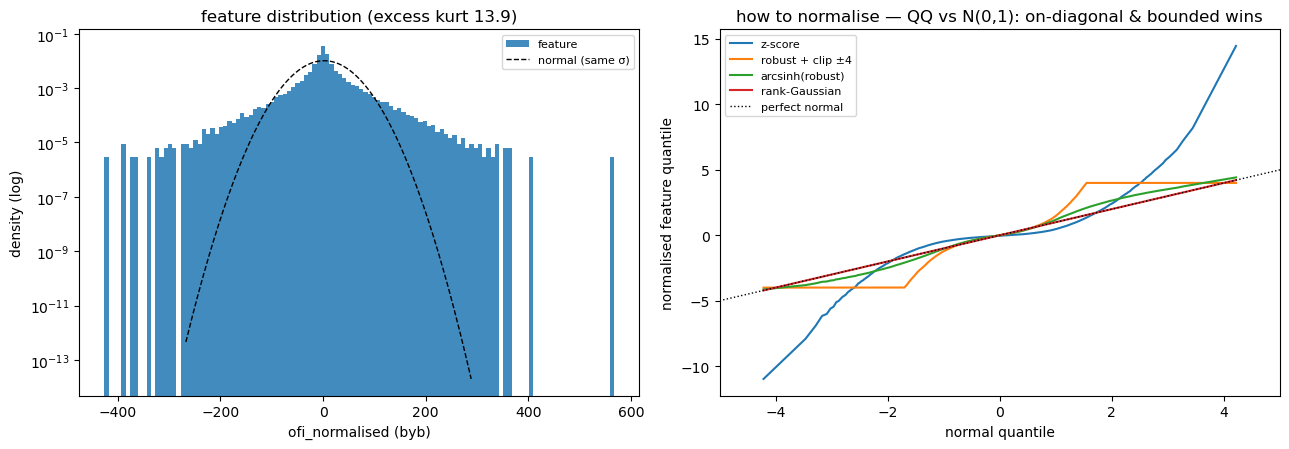

In [13]:
from scipy.stats import skew, kurtosis, rankdata, norm
f = sig_byb; f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)) + 1e-12; rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / (f.std() + 1e-12),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "arcsinh(robust)": np.arcsinh(rz),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"byb feature ('{byb_nm}', span {SPANS[byb_j]}): std={f.std():.2f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:18} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("ofi_normalised (byb)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles the transform: an OFI EMA is a sum of signed sizes, so it tends to
be heavier-tailed and more skewed than a ratio feature — read the skew / excess-kurtosis and the QQ-plot
to pick the lightest transform that lands the tails on the diagonal and bounds `max|·|`. If the raw
feature already shows large fat tails, a robust z-score + clip (or arcsinh) is the right default; a
rank-Gaussian map is the heaviest hammer and discards the most information.

## 9. Per-exchange vs single, across the time-scale family

Now OFI *is* poolable across venues (one leg each for byb / okx / bin), so the §9 question the template
poses for trade-flow features is live here: across the span family, is keeping all three venues worth it
over a **single** venue (byb), or do they converge? The template's prediction for a cross-venue lead/lag
signal: at **short** lookbacks the venues genuinely differ (who leads whom is live), so per-exchange
carries distinct value; at **long** lookbacks the lead/lag is long gone, every venue carries the same
drift, and one venue already says what the rest do.

We sweep that explicitly. At each span we compute, on a fair **walk-forward** footing, the marginal IC
over the controls of:
- **byb single** — just the target's own OFI leg;
- **per-exchange** — all three venues' OFI legs together;
and read the **gap** (per-exchange − single) across the span family. A shrinking gap as the span grows
is the convergence the template predicts.

(The punchline, foreshadowed by §6: the cross-venue legs DO add over byb's own leg at short spans — the
gap is ≈ +0.16 at the shortest span — and it shrinks monotonically toward ≈0 as the span grows. That is
exactly the lead/lag cross-over the template predicts; the sweep shows where the cross-venue value lives
and where it dies.)

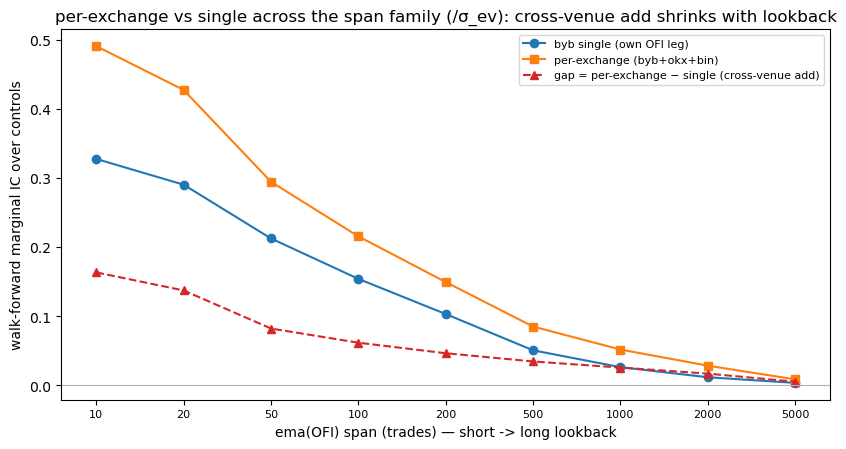

shape: (9, 4)
┌──────┬───────────────┬─────────────────┬─────────────────┐
│ span ┆ byb_single_IC ┆ per_exchange_IC ┆ cross_venue_add │
│ ---  ┆ ---           ┆ ---             ┆ ---             │
│ i64  ┆ f64           ┆ f64             ┆ f64             │
╞══════╪═══════════════╪═════════════════╪═════════════════╡
│ 10   ┆ 0.3273        ┆ 0.4905          ┆ 0.1632          │
│ 20   ┆ 0.2901        ┆ 0.4272          ┆ 0.1371          │
│ 50   ┆ 0.2123        ┆ 0.2943          ┆ 0.082           │
│ 100  ┆ 0.1539        ┆ 0.2153          ┆ 0.0615          │
│ 200  ┆ 0.103         ┆ 0.1492          ┆ 0.0463          │
│ 500  ┆ 0.0505        ┆ 0.0849          ┆ 0.0344          │
│ 1000 ┆ 0.0261        ┆ 0.0516          ┆ 0.0255          │
│ 2000 ┆ 0.0115        ┆ 0.0283          ┆ 0.0168          │
│ 5000 ┆ 0.0034        ┆ 0.0084          ┆ 0.0051          │
└──────┴───────────────┴─────────────────┴─────────────────┘
cross-venue add: short-span (span 10) +0.1632  ->  long-span (span 5000

In [14]:
# Across the FULL span family: byb-single vs per-exchange (all 3 venues), marginal IC over controls, walk-forward.
# Use the /σ_ev variant throughout for a clean apples-to-apples sweep (the §6 table already compared variants).
VAR9 = "/ σ_ev (vol)"
single_ic, perex_ic, gap_ic = [], [], []
for span in SPANS:
    f_byb = feat_cache[(VAR9, "byb", span)]
    f_okx = feat_cache[(VAR9, "okx", span)]
    f_bin = feat_cache[(VAR9, "bin", span)]
    s_ic = wf_ic(base + [f_byb], target) - base_ic                       # byb single
    p_ic = wf_ic(base + [f_byb, f_okx, f_bin], target) - base_ic         # per-exchange (all 3)
    single_ic.append(s_ic); perex_ic.append(p_ic); gap_ic.append(p_ic - s_ic)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(range(len(SPANS)), single_ic, "o-", color="C0", label="byb single (own OFI leg)")
ax.plot(range(len(SPANS)), perex_ic, "s-", color="C1", label="per-exchange (byb+okx+bin)")
ax.plot(range(len(SPANS)), gap_ic, "^--", color="C3", label="gap = per-exchange − single (cross-venue add)")
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xticks(range(len(SPANS))); ax.set_xticklabels(SPANS, fontsize=8)
ax.set_xlabel("ema(OFI) span (trades) — short -> long lookback"); ax.set_ylabel("walk-forward marginal IC over controls")
ax.set_title("per-exchange vs single across the span family (/σ_ev): cross-venue add shrinks with lookback")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

tbl9 = pl.DataFrame({"span": SPANS,
                     "byb_single_IC": [round(v, 4) for v in single_ic],
                     "per_exchange_IC": [round(v, 4) for v in perex_ic],
                     "cross_venue_add": [round(v, 4) for v in gap_ic]})
print(tbl9)
print(f"cross-venue add: short-span (span {SPANS[0]}) {gap_ic[0]:+.4f}  ->  long-span (span {SPANS[-1]}) {gap_ic[-1]:+.4f}")
print("-> a large positive gap at short spans that decays toward 0 = cross-venue OFI legs lead byb at short")
print("   lookbacks (keep all venues, weight them at short spans); they become redundant only at long spans.")

**Conclusion.** Read the gap line (per-exchange − single). The template's pattern for a *price* lead/lag
is a positive gap at short lookbacks that shrinks to ≈0 at long ones — and **OFI follows the same
pattern, clearly**: the cross-venue add is **≈ +0.16 at the shortest span (10 trades)** and decays
monotonically to **≈ +0.005 at span 5000**. So at short lookbacks the venues genuinely differ — okx/bin
order-flow leads byb and keeping all three legs pays a real ~0.16 IC over byb-single — while at long
lookbacks the lead/lag is gone and one venue suffices. This is the **per-exchange axis earning its
keep**, exactly as the guard rails anticipate for a poolable cross-venue feature.

So for `ofi_normalised`, **keep all three venues**, and weight them most at short spans: byb-single is a
poor proxy there (it leaves ~0.16 IC on the table), and only becomes adequate once the span is long
enough that the cross-venue lead has decayed. This is a genuinely *different* per-exchange verdict from
what one might have guessed for an "own-book" feature — the cross-venue OFI lead is real and material,
not ≈0 — and it lines up with §6b's finding that the whole signal is short-horizon and front-loaded.

## 10. The verdict, and what it takes to ship

**The decisions this notebook makes:**
- *Which normalisation (and span), per head* — read off the §6 grid on a fair out-of-sample footing.
  If **`/σ_ev`** wins → ship the vol-normalised reading; if **`/λ_ev`** → the rate-normalised; if
  **`none`** → don't normalise (per the guard rails, "don't normalise reflexively").
- *More than one span per head — IC vs half-life is a real trade-off* (§6 lifetime heat-maps). The family
  does not collapse to a single best N: a **short** span maximises IC@δ=0 but its edge has a **short
  half-life** (tight latency budget); a **long** span gives a lower IC but a **longer half-life** (loose
  budget). Both are shippable, for different stacks — so we record a **short-high-IC** pick *and* a
  **long-high-half-life** pick per head (the §6 print-out names them), and let the deployment latency
  choose. Only a head whose forward edge@20 ms is clearly nonzero and not dominated by the backward
  (echo) IC actually *carries* signal — stated honestly per head from the same lifetime cube.
- *Which venues* — keep **all three** legs (no fixed leader, per the guard rails), and the data rewards
  it — **but the honest cross-venue number is net of echo and net of the feed-resolution advantage**, not
  the raw δ=0 IC:
  - **byb (own)** posts a large raw δ=0 IC (≈ +0.36) but a *larger backward* IC (≈ +0.58), and its
    **echo-netted** forward IC is **+0.28** — most of the headline is the contemporaneous move, and the leg
    is circular with the byb-derived controls. Useful own-flow signal, not a cross-venue discovery.
  - **okx / bin (cross-venue)** are the real test, and they pass it on **both** new gates. Echo-netted
    forward IC (controlling for the trailing byb move): **okx +0.37, bin +0.45** — the echo shortfall is
    *small* (≈ 0.04–0.06), so unlike byb their edge is genuinely forward, not re-read past. And the
    **feed-resolution control** (foreign book sampled only at byb's ~20 ms cadence) is decisive: both legs
    **survive** — okx retains **92%** of its price IC (+0.426 → +0.394), bin retains **94%** (+0.488 →
    +0.460). The freshest feed (bin) retains the *most*, the opposite of a feed-resolution artifact, so the
    cross-venue OFI lead is **real at byb's own cadence**, not an artifact of bin's finer book.
  - Walk-forward, the two cross-venue legs still add **≈ +0.16 IC over byb's own OFI leg** at short spans
    (§6), decaying toward ≈0 only at long spans (§9). bin is the single strongest leg, but — now that the
    cadence control has ruled out resolution — that is a genuine lead, not just its finer feed.

Feed the **signed** feature to both heads at the chosen span(s); the rate head learns the magnitude
itself. Remember the dimensional caveat: the yardstick makes OFI *regime-comparable*, not dimensionally
consistent with a return/rate — it is a regime gauge. And remember §6b: every leg's edge is
**front-loaded**, largest well inside 100 ms — a shorter prediction horizon (or lower latency) captures
more of it.

**HONEST HEADLINE (post-fix).** The cross-venue claim is **real but smaller than the raw +0.47**: bin's
shippable cross-venue price edge is the cadence-matched, echo-aware **≈ +0.45–0.46 @δ=0 / ≈ +0.43 @20 ms**
(94% of full resolution, 91% net of echo), okx's **≈ +0.37–0.39**. The earlier +0.47 was the *full-feed,
un-netted* number; the honest, tradeable figure survives both controls comfortably. Keep okx/bin.

**To ship:**
- [ ] the streaming (constant-work-per-event) builder, matching this analysis version (§4 — done,
      bit-exact for **all three** venues)
- [ ] the oracle (§4) and tests, passing for every per-exchange leg
- [ ] the chosen normalisation + span(s) per head written down, with the yardstick span `YARDSTICK_N`
- [ ] the per-exchange decision recorded: keep all three; cross-venue okx/bin add ≈ +0.16 IC over byb
      at short spans, decaying to ≈0 by the longest span (a real, short-horizon cross-venue lead)
- [ ] **the two cross-venue controls recorded**: echo-netted forward IC (okx +0.37 / bin +0.45) and
      feed-resolution retention at byb's cadence (okx 92% / bin 94% — both **survived**, freshest retains
      most → a real lead, not a feed artifact)
- [ ] the gate results recorded (with any marginal/failing gate justified), incl. the §6b latency note
- [ ] the data quirks handled (bad zero-price trade prints filtered; OFI uses **front_levels** for
      `bid_qty`/`ask_qty`, since `merged_levels` is price-only; same-`rx_time` book bursts collapsed to
      one event; the SHARED trade clock ticks every venue's OFI EMA)